In [ ]:
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_blobs, load_digits
from sklearn.model_selection import train_test_split
import graphviz
from statsmodels.stats.multitest import multipletests
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

11.10.2025

Boots Trap

5.0 5.1625000000000005
True


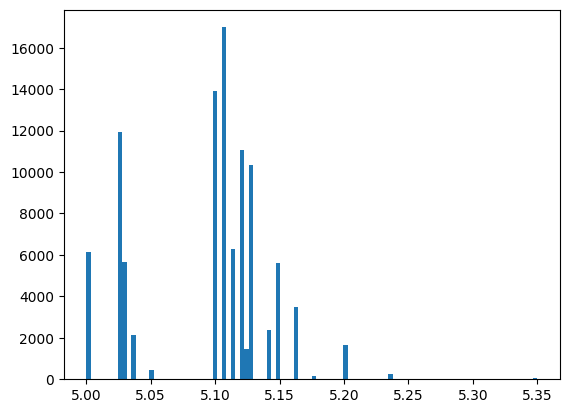

In [ ]:
s = []
X = np.array([5.2, 5.0, 5.35, 5.1, 5.15, 5.12])
for x in range(100000):
  idx = np.random.randint(0, X.shape[0], X.shape[0])
  s.append(np.percentile(X[idx], 25))
s=np.array(s)
print(np.percentile(s, 2.5), np.percentile(s, 97.5))
print(np.percentile(s, 2.5) < 5.1 < np.percentile(s, 97.5))
plt.hist(s, bins = 100);

In [ ]:
start = np.array((0, 3, 2, 5, 9, 7, 0, 2, 3, 3))
N = 10000
cnt = 0
X=np.random.randint(0, 9,(N, 10))
for i in range(N):
  R, p = ss.pearsonr(start, X[i,:])
  if p < 0.05:
    cnt += 1
print(cnt)

546


Поправка Бонферони

In [ ]:
start = np.array((0, 3, 2, 5, 9, 7, 0, 2, 3, 3))
N = 10000
cnt = 0
X=np.random.randint(0, 9,(N, 10))
for i in range(N):
  R, p = ss.pearsonr(start, X[i,:])
  if p < 0.05/N:
    cnt += 1
print(cnt)

0


In [ ]:
INCORRECT=5000
CORRECT=15000
SIZE=10
np.random.seed=0
h0=ss.norm(3,1).rvs(size=(SIZE,INCORRECT))
h1=ss.norm(0,2).rvs(size=(SIZE,CORRECT))
h=np.concatenate((h0,h1),axis=1)
sP = []
for i in range(h.shape[1]):
  m=h[:, i].mean()
  std=h[:, i].std()
  T=(m-0)/(std/np.sqrt(h.shape[0]))
  p_val = 2*(1-ss.t.cdf(abs(T), df=h.shape[0] - 1))
  sP.append(p_val)
sP=np.array(sP)
pv = 0.05/20000
P_u = sP[5000:]
print(P_u[P_u<pv].shape[0], P_u[P_u>pv].shape[0])
P_u = sP[:5000]
print(P_u[P_u<pv].shape[0], P_u[P_u>pv].shape[0])

0 15000
2496 2504


Метод Холма

In [ ]:
reject, p_corrected, a1, a2 = multipletests(sP, alpha=0.05, method='holm')
pv = 0.05
P_u = p_corrected[5000:]
print(P_u[P_u<pv].shape[0], P_u[P_u>pv].shape[0])
P_u = p_corrected[:5000]
print(P_u[P_u<pv].shape[0], P_u[P_u>pv].shape[0])

0 15000
2627 2373


Метод Бенджамини-Хохберга

In [ ]:
reject, p_corrected, a1, a2 = multipletests(sP, alpha=0.05, method='fdr_bh')
pv = 0.05
P_u = p_corrected[5000:]
print(P_u[P_u<pv].shape[0], P_u[P_u>pv].shape[0])
P_u = p_corrected[:5000]
print(P_u[P_u<pv].shape[0], P_u[P_u>pv].shape[0])

248 14752
5000 0


Прогноз котегориальной переменной без учителя (кластеризация)

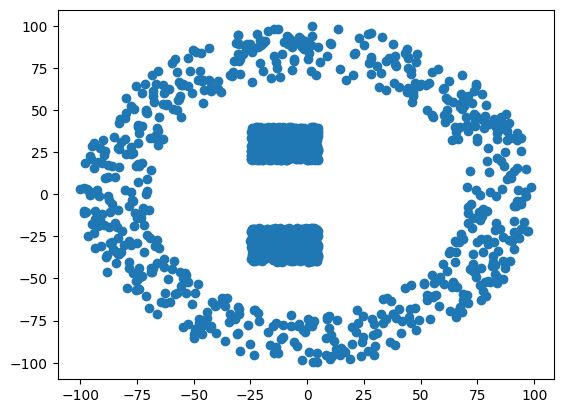

In [ ]:
f = open("src2.dat")
d = []
for s in f:
  d.append([float(x) for x in s.split()])
d = np.array(d)
plt.scatter(d[:, 0], d[:,1])

Алгоритм DBSCAN

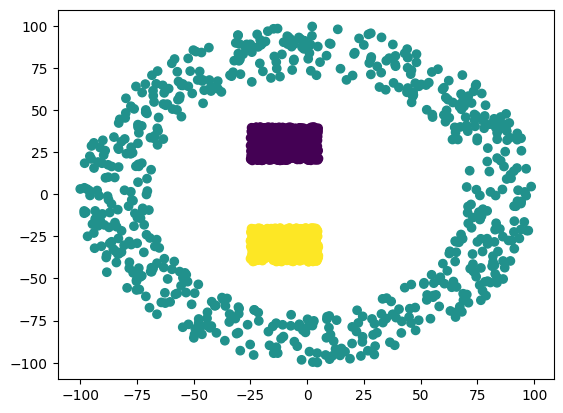

In [ ]:
f = open("src2.dat")
d = []
for s in f:
  d.append([float(x) for x in s.split()])
d = np.array(d)
clf = DBSCAN(10)
c = clf.fit_predict(d)
plt.scatter(d[:, 0], d[:,1], c = c)

3


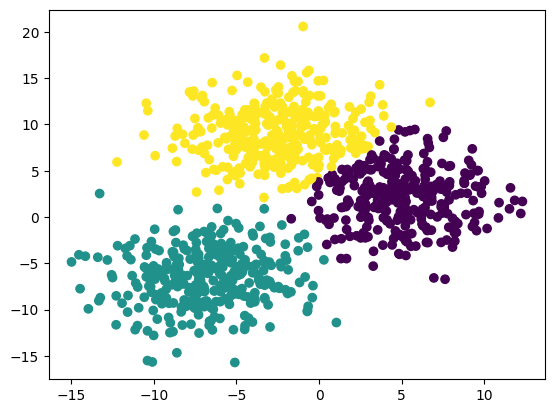

0.6775510204081633 1.2929292929292928


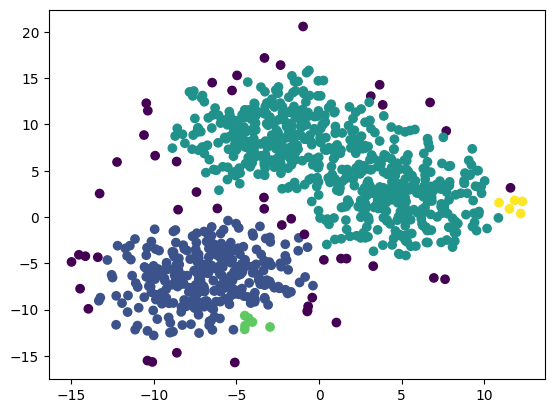

In [ ]:
#f = open("src2.dat")
#d = []
#for s in f:
 # d.append([float(x) for x in s.split()])
#d = np.array(d)

d, y = make_blobs(n_samples=1000, n_features=2, centers=3, cluster_std = 3, random_state=42)

from sklearn.mixture import GaussianMixture
n_opt, c_opt, bic_opt = -1, [], 1e100
for n in range(1, 20):
  clf = GaussianMixture(n_components=n)
  c = clf.fit_predict(d)
  bic = clf.aic(d)
  if bic<bic_opt:
    bic_opt = bic
    n_opt = n
    c_opt = c
print(n_opt)
plt.scatter(d[:, 0], d[:,1], c = c_opt)
plt.show()

#plt.scatter(d[:, 0], d[:,1], c = y)
s_opt = -1e100
e_opt = -1e100
c_opt = []
idx = np.array(range(y.shape[0]))
np.random.shuffle(idx)
idx2 = idx[:50]
from sklearn.metrics import rand_score
for eps in list(np.linspace(1, 30, 100)):
  clf = DBSCAN(eps=eps)
  c = clf.fit_predict(d)
  s=rand_score(y[idx2], c[idx2])
  if(np.unique(c).shape[0]>1):
    if s>s_opt:
      s_opt=s
      e_opt=eps
      c_opt = c
print(s_opt, e_opt)
plt.scatter(d[:, 0], d[:,1], c = c_opt)

18


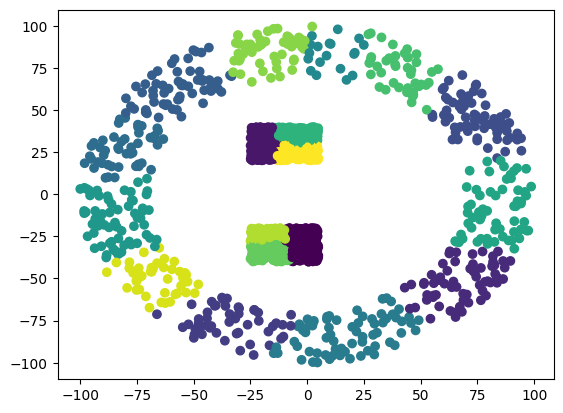

In [ ]:
f = open("src2.dat")
d = []
for s in f:
  d.append([float(x) for x in s.split()])
d = np.array(d)
n_opt, c_opt, bic_opt = -1, [], 1e100
for n in range(1, 20):
  clf = GaussianMixture(n_components=n)
  c = clf.fit_predict(d)
  bic = clf.aic(d)
  if bic<bic_opt:
    bic_opt = bic
    n_opt = n
    c_opt = c
print(n_opt)
plt.scatter(d[:, 0], d[:,1], c = c_opt)
plt.show()

18.10.2025

In [ ]:
data = load_digits()
#plt.title(data.target[145])
#plt.imshow(data.images[145])
print(data.data.shape)
bic_opt, n_opt = 1e100, 1e100
from sklearn.mixture import GaussianMixture
for n in range(1, 30):
  clf = GaussianMixture(n_components=n)
  clf = clf.fit(data.data)
  bic = clf.bic(data.data)
  if bic < bic_opt:
    bic_opt = bic
    n_opt = n
    print(n, bic)

метод случайных проекций

(1797,) (1797,)


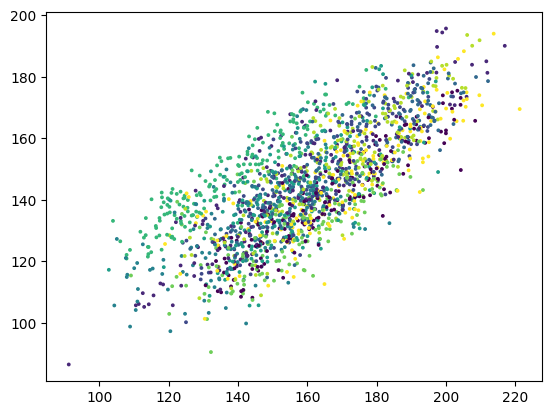

In [ ]:
A = np.random.rand(64)
B = np.random.rand(64)
y0 = data.data@A.T
y1 = data.data@B.T
print(y0.shape, y1.shape)
plt.scatter(y0, y1, c=data.target, s=3)

Линейные методы

(1797,) (1797,)
7.495541943884256


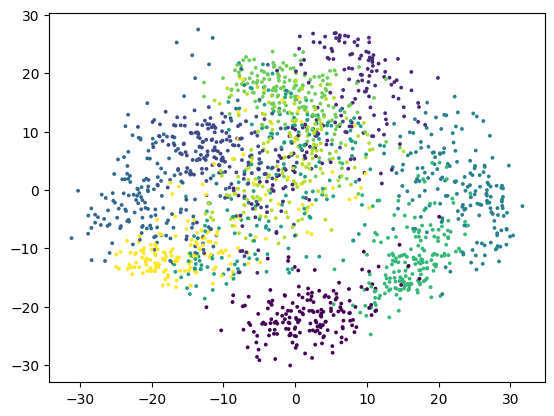

In [ ]:
from sklearn.random_projection import GaussianRandomProjection
import math

#tr = GaussianRandomProjection(n_components=2)
tr = PCA(n_components=2)
y = tr.fit_transform(data.data)

print(y0.shape, y1.shape)
plt.scatter(y[:, 0], y[:, 1], c=data.target, s=3)
print(math.log(1800)) # Смотрим оптимальную размерность

Нелинейные методы

многомерное шкалирование

(1797,) (1797,)


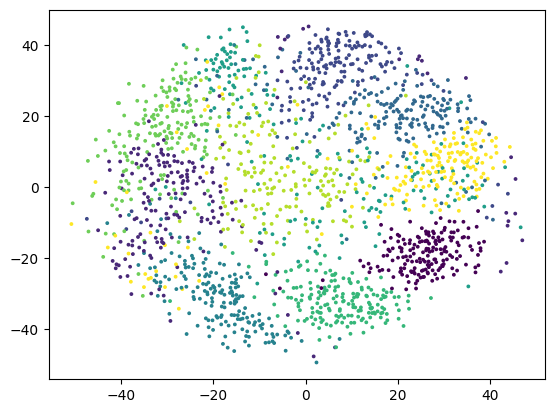

In [ ]:
from sklearn.manifold import MDS

tr = MDS(n_components=2)
y = tr.fit_transform(data.data)

print(y0.shape, y1.shape)
plt.scatter(y[:, 0], y[:, 1], c=data.target, s=3)

SNE

(1797,) (1797,)


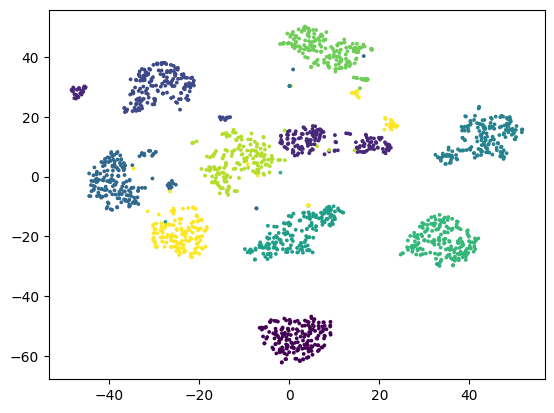

In [ ]:
from sklearn.manifold import TSNE

tr = TSNE(n_components=2)
y = tr.fit_transform(data.data)

print(y0.shape, y1.shape)
plt.scatter(y[:, 0], y[:, 1], c=data.target, s=3)

UMAP

In [ ]:
!pip install umap

(1797,) (1797,)


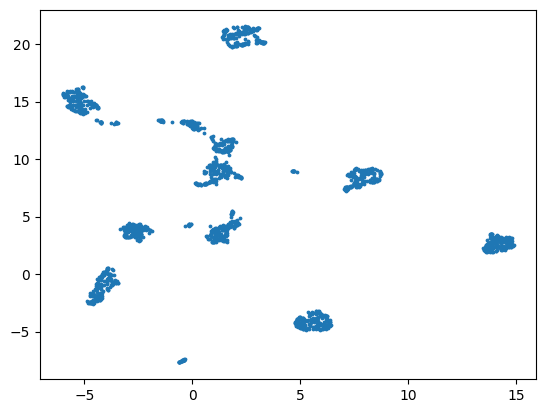

In [ ]:
from umap.umap_ import UMAP

tr = UMAP(n_components=2)
y = tr.fit_transform(data.data)

print(y0.shape, y1.shape)
plt.scatter(y[:, 0], y[:, 1], s=3)

25.10.2025

Линейная регрессия

(100, 1)


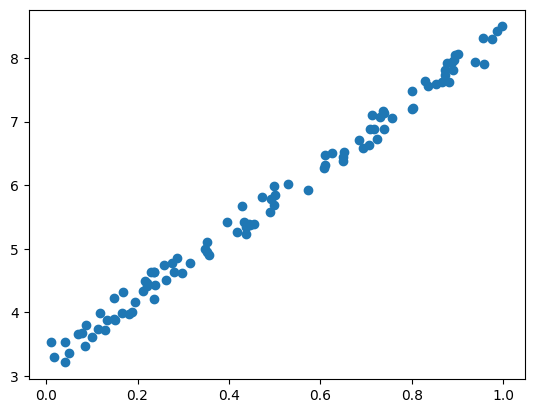

In [ ]:
x=np.random.rand(100,1)
print(x.shape)
y=5.1*x[:,0]+3+np.random.rand(100)*0.5
plt.scatter(x, y)

32.090133005578394 48.41521503860089 100 321.4798187718929 571.5935644789033


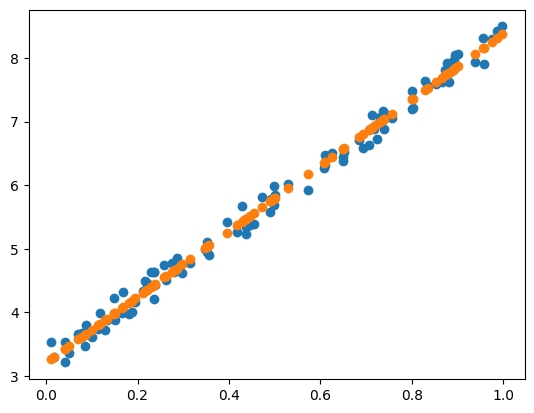

In [ ]:
x_2 = (x**2).sum()
x_1 = (x).sum()
s_1 = x.shape[0]

y_x_s = (y * x[:, 0]).sum()
y_s = (y).sum()
print(x_2, x_1, s_1, y_x_s, y_s)

D0 = x_2 * s_1 - x_1 * x_1
DA = y_x_s * s_1 - y_s * x_1
DB = x_2 * y_s - x_1 * y_x_s
A = DA / D0
B = DB / D0
ym = A*x[:, 0] + B
plt.scatter(x[:, 0], y)
plt.scatter(x[:, 0], ym)

mse:  0.991332416235686
Coefs:  [5.17255339] 3.211632799909546
Coefs A B:  5.172553386126319 3.2116327999095464


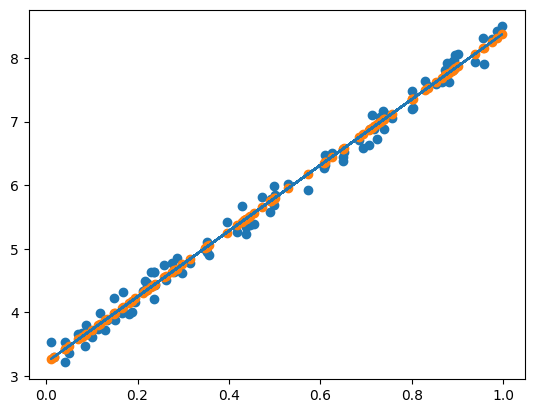

In [ ]:


clf = LinearRegression()
clf.fit(x, y)
print('mse: ', clf.score(x, y))
ym2 = clf.predict(x)
plt.scatter(x[:, 0], y)
plt.scatter(x[:, 0], ym)
plt.plot(x[:, 0], ym2)

print('Coefs: ', clf.coef_, clf.intercept_)
print('Coefs A B: ', A, B)

(100, 3)
mse:  0.9988197678908141
Coefs:  [ 5.05379698  7.09438684 12.10581357] 3.2930569241206182


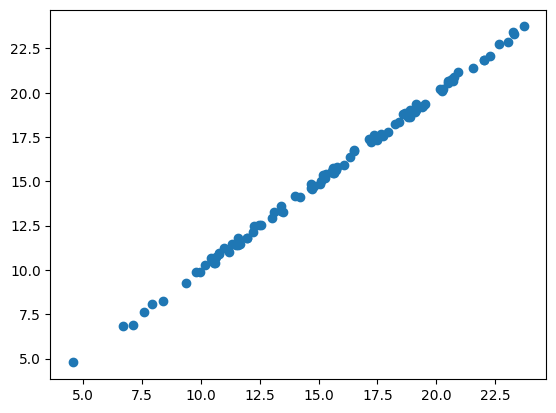

In [ ]:
x=np.random.rand(100,3)
print(x.shape)
y=5.1*x[:,0]+7.1*x[:,1]+12.1*x[:,2]+3+np.random.rand(100)*0.5

clf = LinearRegression()
clf.fit(x, y)
print('mse: ', clf.score(x, y))
ym = clf.predict(x)
plt.scatter(y, ym)
print('Coefs: ', clf.coef_, clf.intercept_)

(442, 10) (442,)
mse:  0.4849058889476756
Coefs:  [  47.74968054 -241.99090728  531.97106288  381.56286182 -918.50290455
  508.25778252  116.95016447  269.4923028   695.80811712   26.32458203] 151.6651755919933


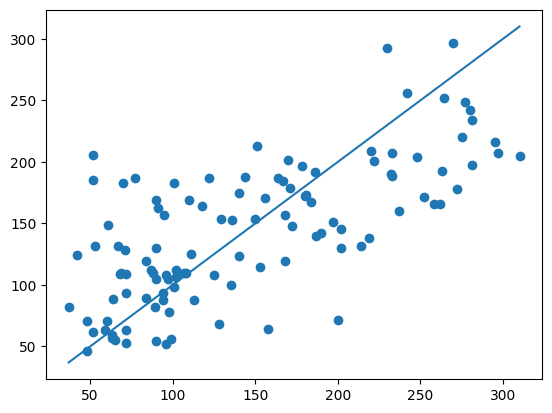

In [ ]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
print(data.data.shape, data.target.shape)
Xtr, Xt, Ytr, Yt = train_test_split(data.data, data.target, random_state=42)

clf = LinearRegression()
clf.fit(Xtr, Ytr)
print('mse: ', clf.score(Xt, Yt))
ym = clf.predict(Xt)
plt.scatter(Yt, ym)
print('Coefs: ', clf.coef_, clf.intercept_)
plt.plot([Yt.min(), Yt.max()], [Yt.min(), Yt.max()])

Data shape: (442, 10) Target shape: (442,)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10000
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 30342.7539 - mse: 30342.7539 - val_loss: 20691.9102 - val_mse: 20691.9121
Epoch 2/10000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 29319.3984 - mse: 29319.3984 - val_loss: 18514.0293 - val_mse: 18514.0293
Epoch 3/10000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 24966.6738 - mse: 24966.6738 - val_loss: 16532.9180 - val_mse: 16532.9180
Epoch 4/10000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 22569.3281 - mse: 22569.3281 - val_loss: 14725.4248 - val_mse: 14725.4248
Epoch 5/10000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19506.0723 - mse: 19506.0723 - val_loss: 13107.1543 - val_mse: 13107.1543
Epoch 6/10000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 19373.2031 - mse: 19373.2031 - val_loss: 11657.6758 - val_mse: 11657.6758
Epoch 7/10000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 16451.5527 - mse: 16451.5527 - val_loss: 10371.1348 - val_mse: 10371.1348
Epoch 8/10000
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 143

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
[<Variable path=sequential_2/dense_2/kernel, shape=(10, 1), dtype=float32, value=[[ 107.180786 ]
 [ -56.81755  ]
 [ 201.99783  ]
 [ 168.45413  ]
 [  21.70381  ]
 [  -2.8841994]
 [-175.81181  ]
 [ 148.6872   ]
 [ 188.86339  ]
 [ 136.27013  ]]>, <Variable path=sequential_2/dense_2/bias, shape=(1,), dtype=float32, value=[150.6147]>]


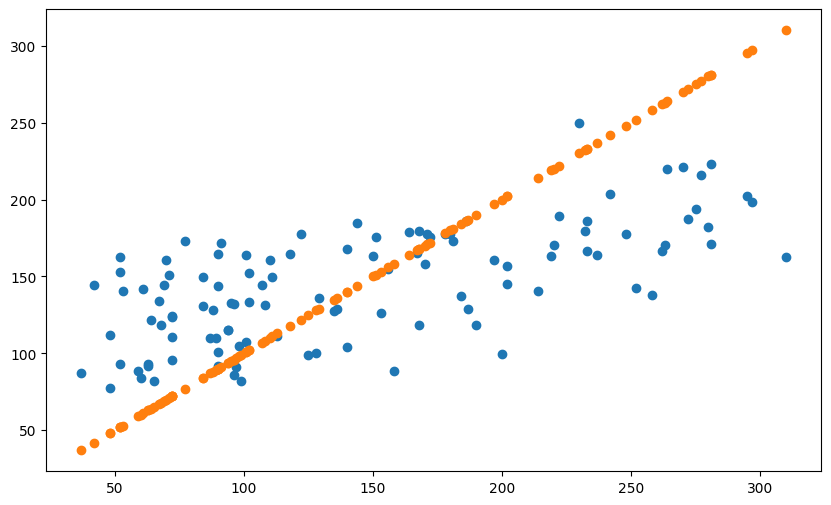

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data = load_diabetes()
print("Data shape:", data.data.shape, "Target shape:", data.target.shape)

Xtr, Xt, Ytr, Yt = train_test_split(data.data, data.target, random_state=42)

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(10,)))
model.add(tf.keras.layers.Dense(1, activation='linear'))
model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e0),
              loss='mse',
              metrics=['mse'])

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=3)

history = model.fit(Xtr, Ytr,
                   validation_split=0.2,
                   epochs=10000,
                   callbacks=[es],
                   verbose=1)

test_loss, test_mse = model.evaluate(Xt, Yt, verbose=0)
print(f"Test MSE: {test_mse}")

ym = model.predict(Xt)

print(model.weights)
plt.figure(figsize=(10, 6))
plt.scatter(Yt, ym)
plt.scatter(Yt, Yt)
plt.show()

(100, 1)
mse:  0.04231187748663967
Coefs:  [772.31645023] -241.68356136176965


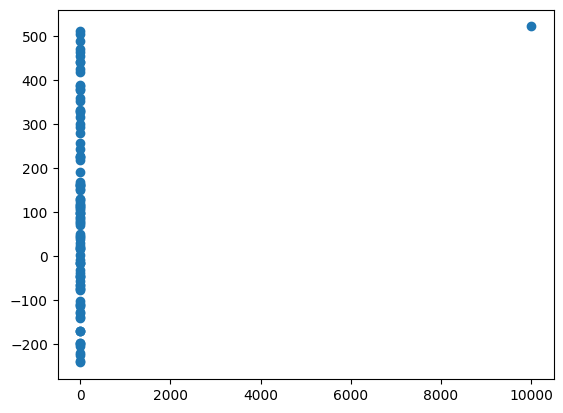

In [ ]:
x=np.random.rand(100,1)
print(x.shape)
y=5.1*x[:,0]+3+np.random.rand(100)*0.5
y[10]=10000

clf = LinearRegression()
clf.fit(x, y)
print('mse: ', clf.score(x, y))
ym = clf.predict(x)
plt.scatter(y, ym)
print('Coefs: ', clf.coef_, clf.intercept_)

Детектор для глобальных минимумов

-621.0899919997441 643.1182611707118


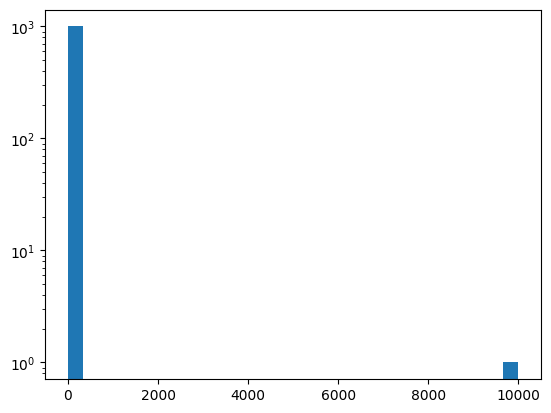

In [ ]:
import matplotlib.pyplot as pp
import numpy as np
import scipy.stats as ss
x=ss.norm(1,3).rvs(1000)
x[50]=1e4
# pp.plot(x)
pp.hist(x,bins=30)
pp.yscale('log')

p1, p2 = x.mean() - 2*x.std(), x.mean() + 2*x.std()
print(p1, p2)

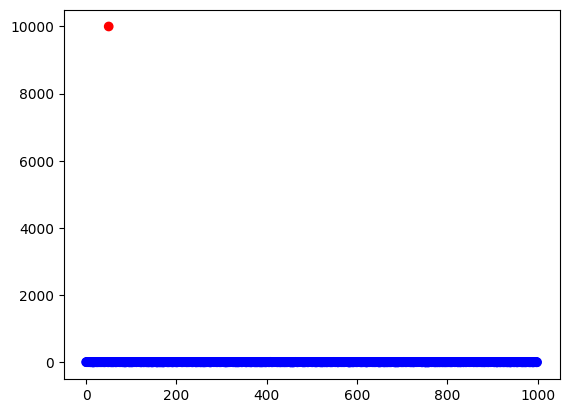

In [ ]:
c = np.array(['blue'] * x.shape[0])
c[x>p2]='red'
c[x<p1]='red'
plt.scatter(range(x.shape[0]), x, c=c)

In [ ]:
x=np.sin(np.array(range(1000))*0.1)
x[20]=1e1
x[35]=1e2

y=ss.norm(1,3).rvs(1000)
p1, p2 = y.mean() - 2*y.std(), y.mean() + 2*y.std()
print(p1, p2)

-5.298881262904988 7.129363551110638


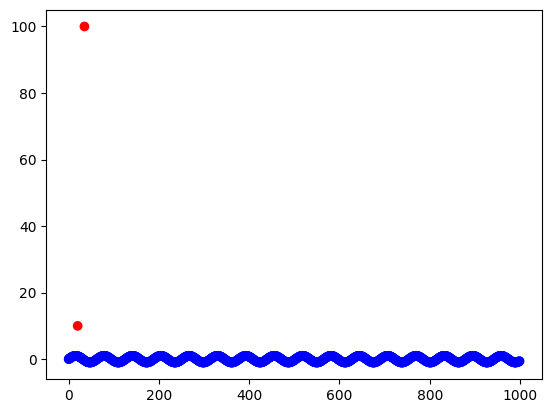

In [ ]:
c = np.array(['blue'] * x.shape[0])
c[x>p2]='red'
c[x<p1]='red'
plt.scatter(range(x.shape[0]), x, c=c)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
titanic_dataset = sns.load_dataset("titanic")
print(titanic_dataset.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


<Axes: xlabel='deck', ylabel='survived'>

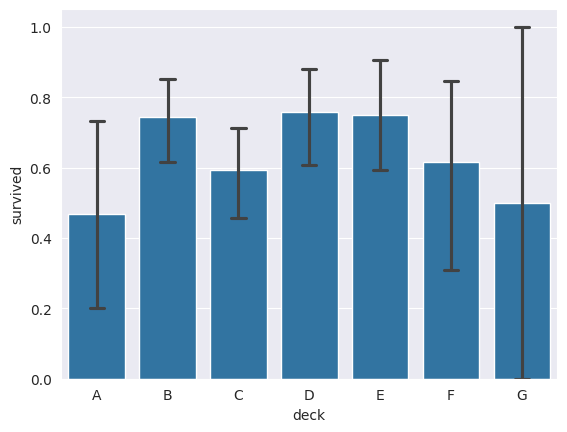

In [ ]:
sns.barplot(x='deck', y = 'survived', data=titanic_dataset, capsize=.2)


<Axes: xlabel='pclass', ylabel='survived'>

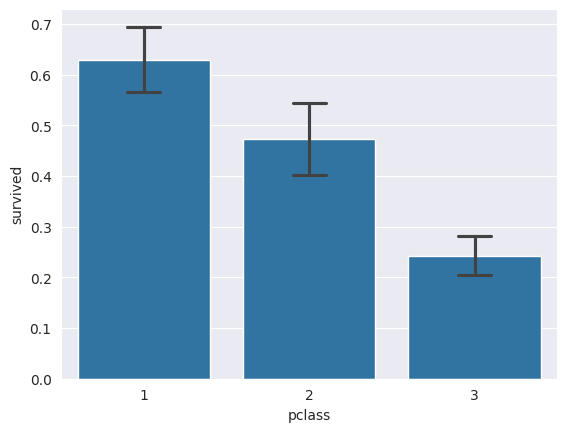

In [ ]:
sns.barplot(x='pclass', y = 'survived', data=titanic_dataset, capsize=.2)


In [ ]:
from pandas import read_csv
from sklearn.model_selection import train_test_split
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/housing.csv'
df = read_csv(url, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


<Axes: xlabel='8', ylabel='13'>

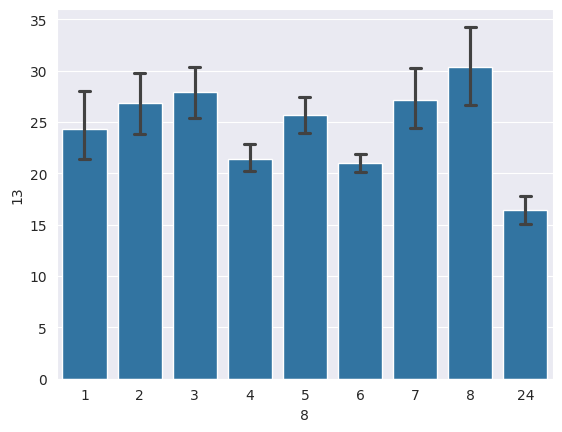

In [ ]:
sns.barplot(x = 8, y = 13, data = df, capsize=.2)

Изолирующий лес

In [ ]:
data = df.values
X, y = data[:, :-1], data[:, -1]
print(X.shape, y.shape)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(506, 13) (506,)
(339, 13) (167, 13) (339,) (167,)


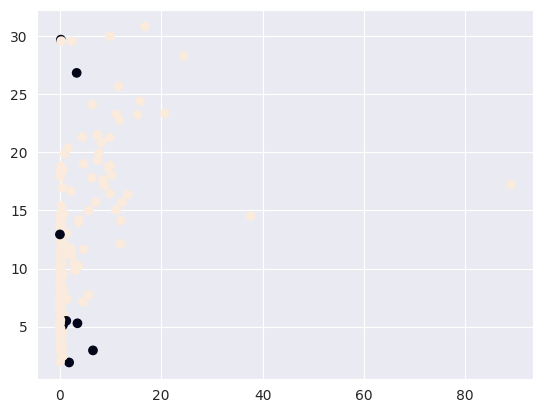

In [ ]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination = 0.05)
iso = iso.fit(X_train)
yhat = iso.predict(X_test)
plt.scatter(X_test[:,0], X_test[:, 12], c=yhat)

Кластеризация

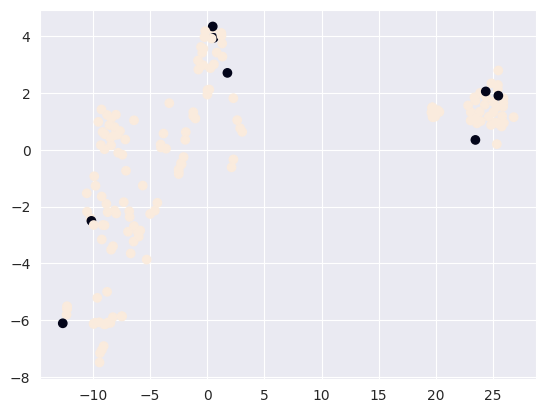

In [ ]:
from sklearn.manifold import TSNE
Xn = TSNE(n_components = 2).fit_transform(X_test)
plt.scatter(Xn[:, 0], Xn[:, 1], c=yhat)

SVM

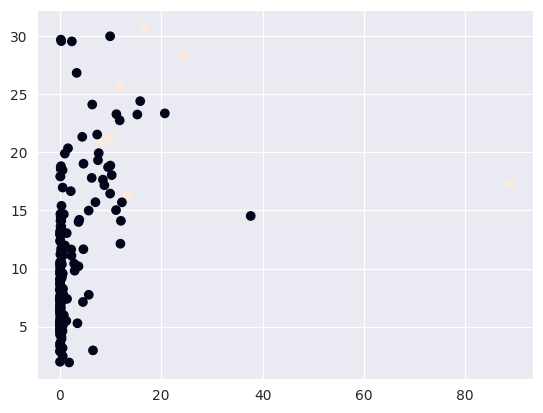

In [ ]:
from sklearn.svm import OneClassSVM
clf = OneClassSVM(gamma = 'auto', kernel='linear', nu=0.95).fit(X_train)
y_hat = clf.predict(X_test)
plt.scatter(X_test[:, 0], X_test[:, 12], c = y_hat)

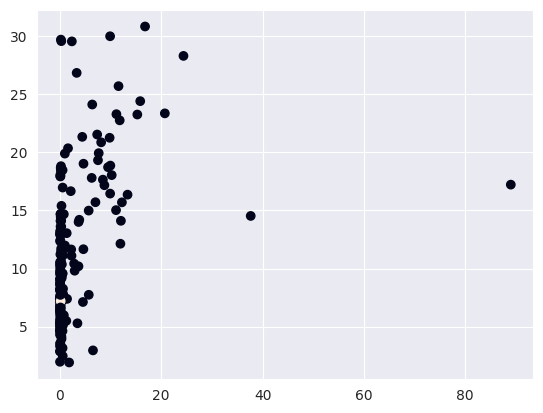

In [ ]:
from sklearn.svm import OneClassSVM
clf = OneClassSVM(gamma = 'auto', nu=0.95).fit(X_train)
y_hat = clf.predict(X_test)
plt.scatter(X_test[:, 0], X_test[:, 12], c = y_hat)

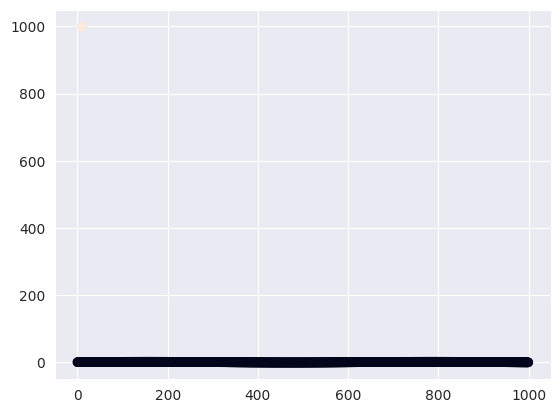

In [ ]:
import numpy as np
x=np.sin(np.linspace(0,10,1000))
x[10]=1e3

x2 = np.expand_dims(x, axis=-1)
clf = clf = OneClassSVM(gamma = 'auto', nu=0.999, kernel='linear').fit(x2)
y_hat = clf.predict(x2)
plt.scatter(range(x.shape[0]),x,c=y_hat)

Эллептические методы

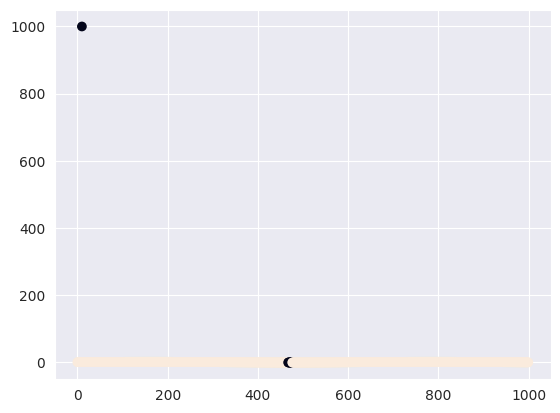

In [ ]:
from sklearn.covariance import EllipticEnvelope
ee = EllipticEnvelope(contamination = 0.01)
yp = ee.fit_predict(x2)
plt.scatter(range(x.shape[0]), x, c=yp)

Локальный уровень выброса

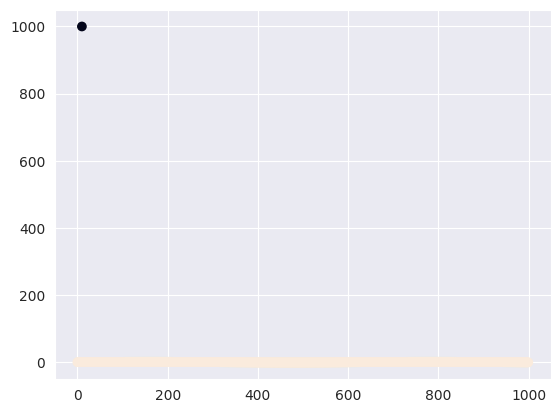

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(novelty = True)
lof = lof.fit(x2)
y_hat = lof.predict(x2)
plt.scatter(range(x.shape[0]), x, c = y_hat)

BDSCAN

In [ ]:
from sklearn.cluster import DBSCAN
for eps in np.linspace(0.1, 200, 100):
  ee = DBSCAN(eps = eps, min_samples = 2)
  yhat = ee.fit_predict(x2)
  yhat = np.array(yhat)
  if yhat[yhat<0].shape[0] < 0.1 * yhat.shape[0]:
    break
x2 = np.array()

Для контекстных и групповых аномалий

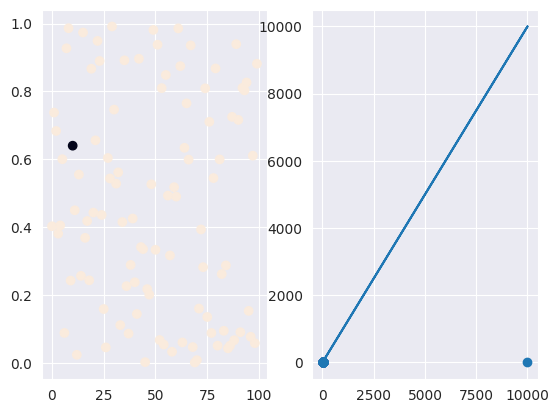

In [ ]:
x = np.random.rand(100, 1)
y=5.1*x[:,0]+3+np.random.rand(100)*0.5
y[10]=10000
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(novelty = True)
lof = lof.fit(y.reshape(-1,1))
y_hat = lof.predict(y.reshape(-1,1))
plt.subplot(1, 2, 1)
plt.scatter(range(x.shape[0]), x, c = y_hat)
plt.subplot(1, 2, 2)
plt.scatter(y, y_hat)
plt.plot(y, y)

31.10.2025

Регуляризация

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, ridge_regression
from sklearn.metrics import r2_score

x = np.random.rand(1000, 1) * 100
x3=np.concatenate([x,x*10+np.random.rand(1000,1)*0.1,x*30+np.random.rand(1000,1)*0.1],axis=1)
print(x3.shape)

y = 5.1 * x[:, 0] + 5 * np.sin(x[:, 0]) + 3
print(y.shape)

model = LinearRegression()
model.fit(x3, y)

y_pred = model.predict(x3)

score = r2_score(y, y_pred)
score_alt = model.score(x3, y)

print(f"{score}")
print(f"{model.coef_}")
print(f"{model.intercept_}")

(1000, 3)
(1000,)
0.9994070779090982
[101.29218571  -4.94207029  -1.55943749]
3.9856460871661454


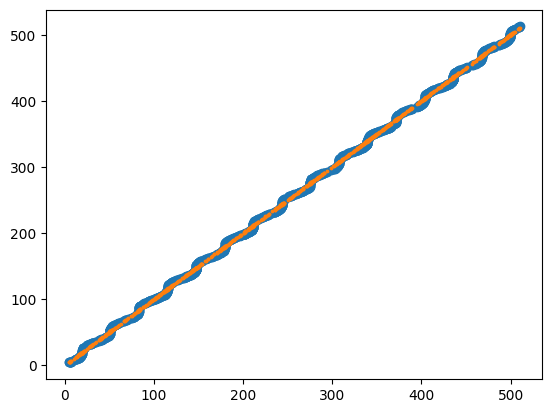

In [ ]:
plt.scatter(y, y_pred)
plt.scatter(y, y, s=3)

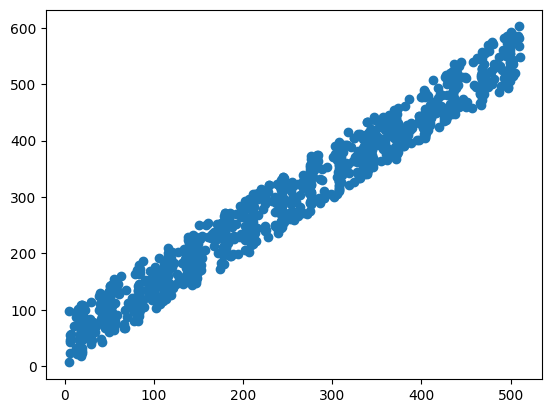

In [ ]:
x4 = x3 + np.random.rand(1000, 1) * 1.
y_p = model.predict(x4)

plt.scatter(y, y_p)

Регуляризаторы

1.   L2 - сумма модулей квадратных от коэффицентов (Ridge) (ослабить значения)
2.   L1 - сумма модулей от коэффицентов (Lasso) (занулить значения)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

x = np.random.rand(1000, 1) * 100
x3=np.concatenate([x,x*10+np.random.rand(1000,1)*0.1,x*30+np.random.rand(1000,1)*0.1],axis=1)
print(x3.shape)

y = 5.1 * x[:, 0] + 5 * np.sin(x[:, 0]) + 3
print(y.shape)

model = Ridge()
model.fit(x3, y)

y_pred = model.predict(x3)

score = r2_score(y, y_pred)
score_alt = model.score(x3, y)

print(f"{score}")
print(f"{model.coef_}")
print(f"{model.intercept_}")

(1000, 3)
(1000,)
0.9993921528260568
[-0.05662231 -0.59202565  0.36919035]
3.010051374873683


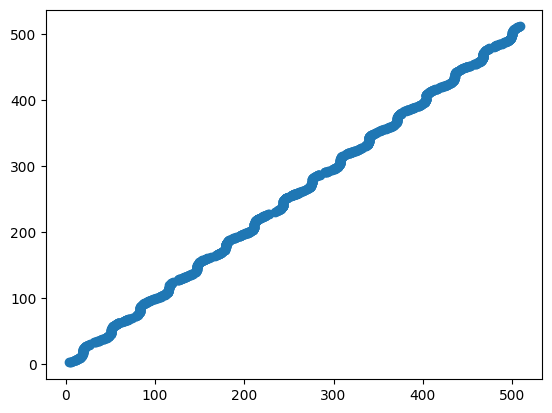

In [ ]:
x4 = x3 + np.random.rand(1000, 1) * 1.
y_p = model.predict(x4)

plt.scatter(y, y_p)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score

x = np.random.rand(1000, 1) * 100
x3=np.concatenate([x,x*10+np.random.rand(1000,1)*0.1,x*30+np.random.rand(1000,1)*0.1],axis=1)
print(x3.shape)

y = 5.1 * x[:, 0] + 5 * np.sin(x[:, 0]) + 3
print(y.shape)

model = Lasso(alpha=3)
model.fit(x3, y)

y_pred = model.predict(x3)

score = r2_score(y, y_pred)
score_alt = model.score(x3, y)

print(f"{score}")
print(f"{model.coef_}")
print(f"{model.intercept_}")

(1000, 3)
(1000,)
0.999418407294244
[1.54651841 0.33084955 0.00816728]
2.9178382737035804


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.147e+03, tolerance: 2.124e+03
  model = cd_fast.enet_coordinate_descent(


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
import tensorflow as tf

x = np.random.rand(1000, 1) * 100
x3=np.concatenate([x,x*10+np.random.rand(1000,1)*0.1,x*30+np.random.rand(1000,1)*0.1],axis=1)
print(x3.shape)

y = 5.1 * x[:, 0] + 5 * np.sin(x[:, 0]) + 3
print(y.shape)

model = LinearRegression()
model.fit(x3, y)

y_pred = model.predict(x3)

score = r2_score(y, y_pred)
score_alt = model.score(x3, y)

model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Input(shape=(3,)))
model2.add(tf.keras.layers.Dense(1, activation='linear', kernel_regularizer='l2', bias_regularizer='l2'))
model2.add(tf.keras.layers.Dense(1, activation='linear'))
model2.summary()

tf.keras.utils.plot_model(model2, show_layer_activations=True, show_shapes=True)

model2.compile(optimizer='adam', loss='mse')
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=5, restore_best_weights=True)

hist = model2.fit(x3, y, validation_split=0.2, shuffle=True, epochs=50, callbacks=[es])
model2.evaluate(x4, y)
print(model2.weights)


(1000, 3)
(1000,)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1012980.1875 - val_loss: 909345.8125
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 841120.7500 - val_loss: 802763.4375
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 759906.6250 - val_loss: 705944.2500
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 712867.5625 - val_loss: 618029.8125
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 590980.0625 - val_loss: 539747.3750
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 533134.0000 - val_loss: 468180.5312
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 437565.1875 - val_loss: 405498.3125
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 382708.5000 - val_loss: 348398.1562
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 334093.8125 - val_loss: 298756.0938
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 281135.4688 - val_loss: 254509.5781
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss:

Ridge

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
import tensorflow as tf

x = np.random.rand(1000, 1) * 100
x3=np.concatenate([x,x*10+np.random.rand(1000,1)*0.1,x*30+np.random.rand(1000,1)*0.1],axis=1)
print(x3.shape)

y = 5.1 * x[:, 0] + 5 * np.sin(x[:, 0]) + 3
print(y.shape)

model = LinearRegression()
model.fit(x3, y)

y_pred = model.predict(x3)

score = r2_score(y, y_pred)
score_alt = model.score(x3, y)

model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Input(shape=(3,)))
model2.add(tf.keras.layers.Dense(1, activation='linear', kernel_regularizer='l2', bias_regularizer='l2'))
model2.summary()

tf.keras.utils.plot_model(model2, show_layer_activations=True, show_shapes=True)

model2.compile(optimizer='adam', loss='mse')
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=5, restore_best_weights=True)

hist = model2.fit(x3, y, validation_split=0.2, shuffle=True, epochs=50, callbacks=[es])
model2.evaluate(x4, y)
print(model2.weights)

(1000, 3)
(1000,)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2075399.3750 - val_loss: 2030688.0000
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1859347.7500 - val_loss: 1867360.0000
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1754753.3750 - val_loss: 1712142.7500
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1571184.8750 - val_loss: 1568170.7500
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1411939.5000 - val_loss: 1433265.5000
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1234987.1250 - val_loss: 1306891.6250
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1158526.0000 - val_loss: 1188405.2500
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1073611.2500 - val_loss: 1078158.7500
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 936481.1250 - val_loss: 977108.1875
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 849122.6875 - val_loss: 882858.0625
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 

Lasso

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
import tensorflow as tf

x = np.random.rand(1000, 1) * 100
x3=np.concatenate([x,x*10+np.random.rand(1000,1)*0.1,x*30+np.random.rand(1000,1)*0.1],axis=1)
print(x3.shape)

y = 5.1 * x[:, 0] + 5 * np.sin(x[:, 0]) + 3
print(y.shape)

model = LinearRegression()
model.fit(x3, y)

y_pred = model.predict(x3)

score = r2_score(y, y_pred)
score_alt = model.score(x3, y)

model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Input(shape=(3,)))
model2.add(tf.keras.layers.Dense(1, activation='linear', kernel_regularizer='l1', bias_regularizer='l1'))
model2.summary()

tf.keras.utils.plot_model(model2, show_layer_activations=True, show_shapes=True)

model2.compile(optimizer='adam', loss='mse')
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=5, restore_best_weights=True)

hist = model2.fit(x3, y, validation_split=0.2, shuffle=True, epochs=50, callbacks=[es])
model2.evaluate(x4, y)
print(model2.weights)

(1000, 3)
(1000,)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4317802.0000 - val_loss: 4221624.0000
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 3806208.0000 - val_loss: 3992003.7500
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3891358.7500 - val_loss: 3768813.7500
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3764645.7500 - val_loss: 3557680.7500
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3581826.7500 - val_loss: 3355689.2500
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3395788.7500 - val_loss: 3163251.0000
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3146981.2500 - val_loss: 2979135.0000
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2984547.7500 - val_loss: 2805206.0000
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2811267.5000 - val_loss: 2636464.2500
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2508755.0000 - val_loss: 2476954.7500
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 344.2395 - val_loss: 206.4257
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 186.7374 - val_loss: 79.8206
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 59.6867 - val_loss: 15.3683
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.3944 - val_loss: 4.0570
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.3611 - val_loss: 3.5194
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.5639 - val_loss: 3.3409
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.8543 - val_loss: 3.3010
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13.1127 - val_loss: 3.2847
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 48.7067 - val_loss: 3.2790
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7634 - val_loss: 3.3799
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


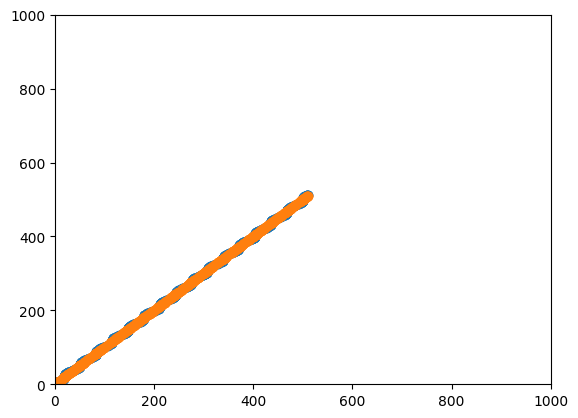

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score
import tensorflow as tf

x=np.random.rand(1000,1)*100
y=5.1*x[:,0]+5*np.sin(x[:,0])+3+np.random.rand(1000)*0.5
y[100]=10000

model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Input(shape=(1,)))
model2.add(tf.keras.layers.Dense(1, activation='linear'))
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='mae')
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=1, restore_best_weights=True)

hist = model2.fit(x, y, validation_split=0.2, shuffle=True, epochs=50, callbacks=[es])
yp= model2.predict(x)
plt.xlim(0, 1000)
plt.ylim(0, 1000)
plt.scatter(y, yp)
plt.scatter(y, y)

01.11.2025

Методы повышения размерности

Когда данных очень много, задача трудная, но данные маленькие

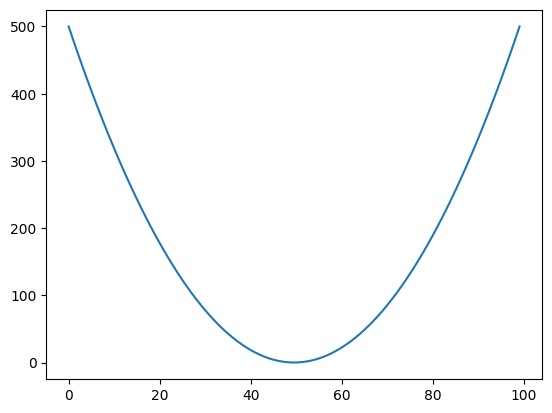

In [ ]:
def parab(x):
  return 5 * x**2 + 0 * x + 0

x = np.linspace(-10, 10, 100)
plt.plot(parab(x))

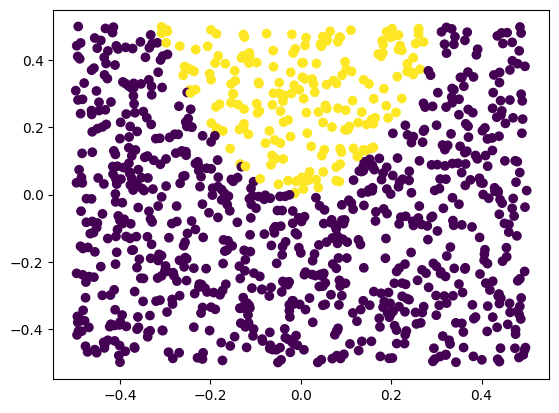

In [ ]:
x = (np.random.rand(1000, 2)-0.5) * 1
c = (x[:, 1] > parab(x[:, 0])).astype(int)
plt.scatter(x[:, 0], x[:, 1], c = c)

In [ ]:
x2 = np.concatenate([x, x[:, 0:1] ** 2], axis=1)
print(x2.shape)

(1000, 3)


In [ ]:
clf=DecisionTreeClassifier(max_depth=2)
clf.fit(x2, c)

import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(clf, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("mytree_source")
print(clf.score(x2, c))

0.95


Полимиальное повышение размерности (Polynomial features)

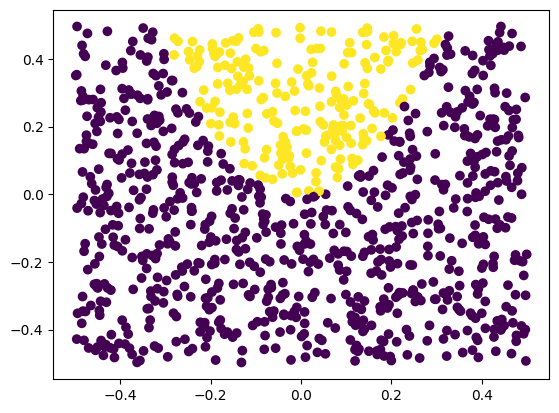

In [ ]:
def parab(x):
  return 5 * x**2 + 0 * x + 0

x = np.linspace(-10, 10, 100)
x = (np.random.rand(1000, 2)-0.5) * 1
c = (x[:, 1] > parab(x[:, 0])).astype(int)
plt.scatter(x[:, 0], x[:, 1], c = c)

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
tr = PolynomialFeatures(2)
x2 = tr.fit_transform(x)
print(x2.shape)

(1000, 6)


In [ ]:
clf=DecisionTreeClassifier(max_depth=2)
clf.fit(x2, c)

import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(clf, out_file=None)
graph = graphviz.Source(dot_data)
graph.render("mytree_source")
print(clf.score(x2, c))

0.955


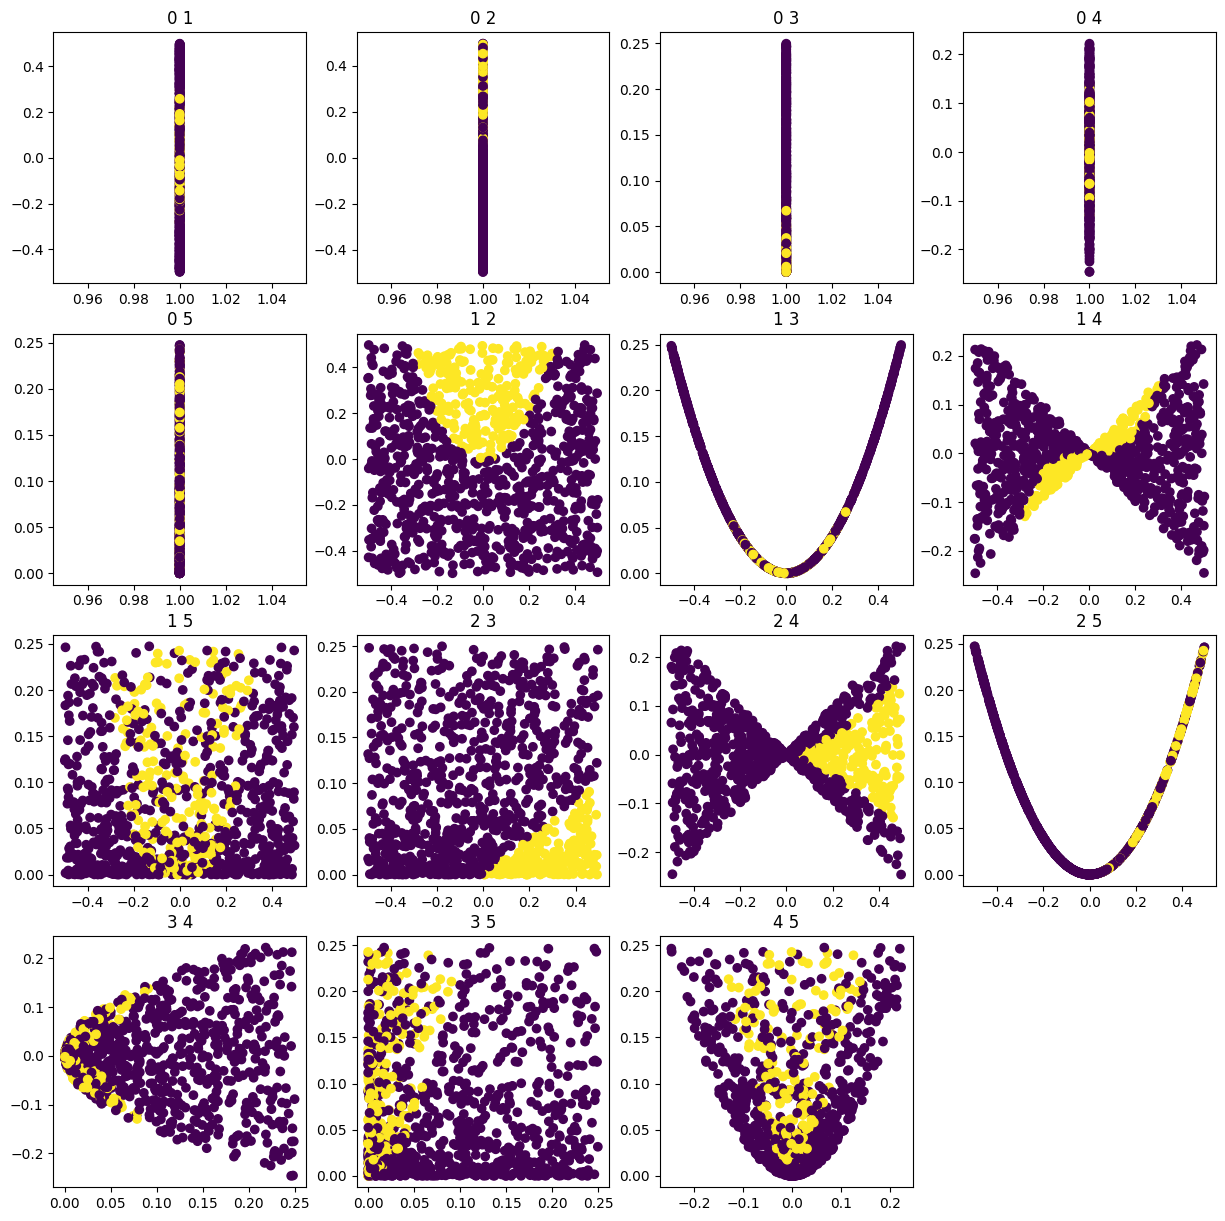

In [ ]:
k = 1
plt.figure(figsize=(15, 15))
for i in range(x2.shape[1]):
  for j in range(i+1, x2.shape[1]):
    plt.subplot(4, 4, k)
    plt.scatter(x2[:, i], x2[:, j], c = c)
    plt.title(str(i) + ' ' +str(j))
    k+=1

In [ ]:
import tensorflow as tf
model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Input(shape=(6,)))
model2.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='bce', metrics=['accuracy'])
model2.fit(x2, c, epochs=100)


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7789 - loss: 0.4849
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8329 - loss: 0.3339
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8751 - loss: 0.2808
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8702 - loss: 0.2741
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8816 - loss: 0.2438
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9005 - loss: 0.2352
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8968 - loss: 0.2201
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9286 - loss: 0.1928
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9378 - loss: 0.1901
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9414 - loss: 0.1758
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9517 - loss: 0.1674
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy

Feature importance

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
data,target=make_regression(n_samples=1000,n_features=6,n_informative=3, noise=10)
print(data.shape)
print(target.shape)

(1000, 6)
(1000,)


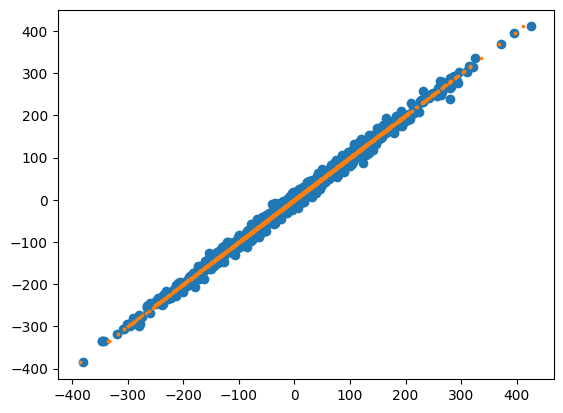

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(data, target)
yp = model.predict(data)

plt.scatter(target, yp)
plt.scatter(yp, yp, s=3)

In [ ]:
from scipy.stats import pearsonr

for i in range(data.shape[1]):
  corr, pvalue = pearsonr(data[:, i], target)
  print(f'i = {i}, corr = {corr} , pval = {pvalue}')
  if pvalue < 0.05:
    print(corr)
  print()

i = 0, corr = 0.6622900390422322 , pval = 2.862526864207542e-127
0.6622900390422322

i = 1, corr = 0.0003699956311130556 , pval = 0.9906764078461191

i = 2, corr = 0.1702057916508846 , pval = 6.12176817793035e-08
0.1702057916508846

i = 3, corr = -0.01255064855360393 , pval = 0.6918058545272878

i = 4, corr = -0.018247865420351957 , pval = 0.5643621198925387

i = 5, corr = 0.700483167227491 , pval = 2.219274679319577e-148
0.700483167227491



08.11.2025

Одномерные методы

In [ ]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
data=load_iris()
print(data.data.shape)
print(data.target.shape)

print(data.data)
print(data.target)

(150, 4)
(150,)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1

In [ ]:
import scipy.stats as ss
for i in range(data.data.shape[1]):
 print(i, ss.spearmanr(data.data[:, i], data.target))

0 SignificanceResult(statistic=np.float64(0.7980781172420549), pvalue=np.float64(2.2480123863519486e-34))
1 SignificanceResult(statistic=np.float64(-0.440289584131434), pvalue=np.float64(1.7202976350970525e-08))
2 SignificanceResult(statistic=np.float64(0.9354305169914044), pvalue=np.float64(1.0190926413962842e-68))
3 SignificanceResult(statistic=np.float64(0.9381791663400608), pvalue=np.float64(4.5136319916083155e-70))


Многомерные методы

[-0.09235605 -0.01741097  0.40227899  0.46284429] 0.18649524720625055


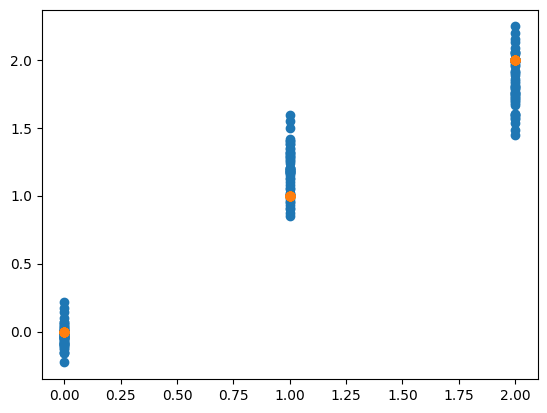

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = data.data
for i in range(X.shape[1]):
  X[:, i] /= X[:, i].std()
model.fit(X, data.target)
print(model.coef_, model.intercept_)
yp = model.predict(data.data)

plt.scatter(data.target, yp)
plt.scatter(data.target, data.target)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
X = data.data
model.fit(X, data.target)
for i in range(X.shape[1]):
  X[:, i] /= X[:, i].std()
print(model.coef_*X.std(axis=0), model.intercept_)

from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X, data.target)
print(model.feature_importances_)

[-0.09235605 -0.01741097  0.40227899  0.46284429] 0.18649524720625055
[0.00666667 0.00666667 0.77536131 0.21130535]


In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = DecisionTreeRegressor()
model.fit(X, data.target)
print(model.feature_importances_)

[0.00666667 0.         0.03202798 0.96130535]


In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = DecisionTreeRegressor()
model.fit(X, data.target)

import numpy as np
print(model.score(X, data.target))
for i in range(X.shape[1]):
  Xt = X.copy()
  np.random.shuffle(Xt[:, i])
  print(i, model.score(Xt, data.target))
# Это одномерный метод

1.0
0 0.99
1 1.0
2 -0.77
3 0.81


In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = DecisionTreeRegressor()
model.fit(X, data.target)

import numpy as np
print(model.score(X, data.target))
for i in range(X.shape[1]):
  for j in range(i+1, X.shape[1]):
    Xt = X.copy()
    np.random.shuffle(Xt[:, i])
    np.random.shuffle(Xt[:, j])
    print(i, j , model.score(Xt, data.target))

1.0
0 1 0.98
0 2 -0.73
0 3 0.79
1 2 -0.8
1 3 0.84
2 3 -0.8899999999999999


In [ ]:
import tensorflow as tf
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(4,)))
model.add(tf.keras.layers.Dense(5,activation='relu'))
model.add(tf.keras.layers.Dense(5,activation='relu'))
model.add(tf.keras.layers.Dense(1,activation='linear'))
model.summary()
tf.keras.utils.plot_model(model,show_shapes=True,show_layer_activations=True,to_file='mm.png')
model.compile(optimizer='adam',loss='mae')
es=tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',patience=3,restore_best_weights=True)
model.fit(X,data.target,epochs=10000,validation_split=0.2, callbacks=[es])

import numpy as np
y0=model.predict(X)[:,0]
print('Q0:',(y0-data.target).std())
for i in range(X.shape[1]):
 for j in range(i+1,X.shape[1]):
  Xt=X.copy()
  np.random.shuffle(Xt[:,i])
  np.random.shuffle(Xt[:,j])
  y1=model.predict(Xt)[:,0]
  print('Q[',i,',',j,']:',(y1-data.target).std())

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_81 (Dense)                │ (None, 5)              │            25 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - loss: 0.9337 - val_loss: 2.2705
Epoch 2/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.8591 - val_loss: 2.2393
Epoch 3/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.8885 - val_loss: 2.2094
Epoch 4/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8863 - val_loss: 2.1815
Epoch 5/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8317 - val_loss: 2.1573
Epoch 6/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8180 - val_loss: 2.1359
Epoch 7/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7720 - val_loss: 2.1165
Epoch 8/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.8531 - val_loss: 2.0982
Epoch 9/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.7804 - val_loss: 2.0812
Epoch 10/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.7443 - val_loss: 2.0653
Epoch 11/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.8200 - val_loss: 2.0499
Epoch 12/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

KeyboardInterrupt: 

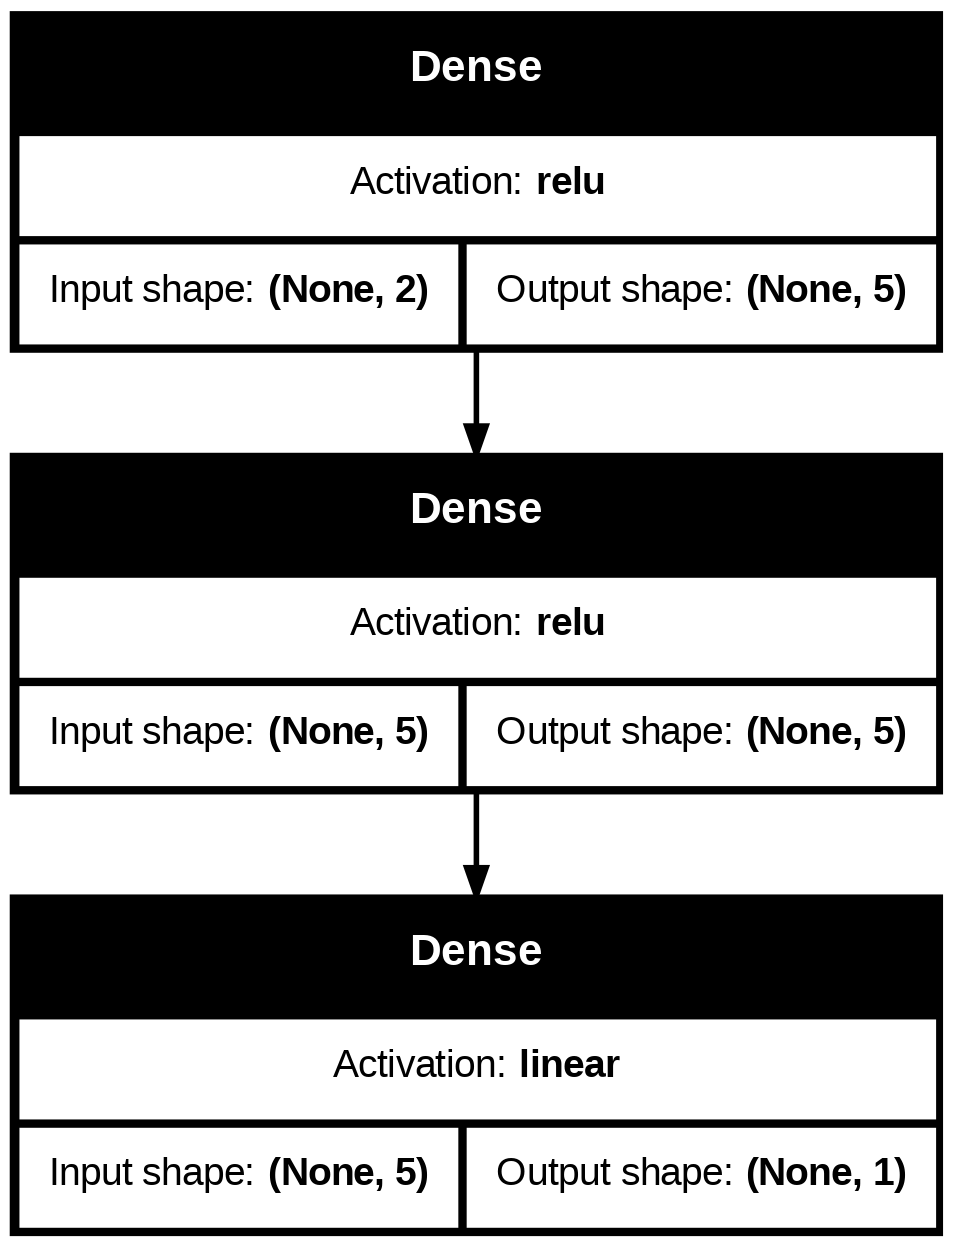

In [ ]:
import tensorflow as tf
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(2,)))
model.add(tf.keras.layers.Dense(5,activation='relu'))
model.add(tf.keras.layers.Dense(5,activation='relu'))
model.add(tf.keras.layers.Dense(1,activation='linear'))
tf.keras.utils.plot_model(model,show_shapes=True,show_layer_activations=True,to_file='mm.png')

In [ ]:

model.compile(optimizer='adam',loss='mae')
es=tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',patience=3,restore_best_weights=True)
model.fit(X[:, 2:],data.target,epochs=10000,validation_split=0.2, callbacks=[es])

import numpy as np
y0=model.predict(X[:, 2:])[:,0]
print('Q0:',(y0-data.target).std())

In [ ]:
import tensorflow as tf
Y = tf.keras.utils.to_categorical(data.target)
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(4,)))
model.add(tf.keras.layers.Dense(5,activation='relu'))
model.add(tf.keras.layers.Dense(5,activation='relu'))
model.add(tf.keras.layers.Dense(3,activation='softmax'))
tf.keras.utils.plot_model(model,show_shapes=True,show_layer_activations=True)

model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
es=tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',patience=3,restore_best_weights=True)
model.fit(X,Y,epochs=10000,validation_split=0.2, callbacks=[es])

import numpy as np
y0=np.argmax(model.predict(X), axis=-1)

def acc(y, y0):
  return((y==y0).astype(int)).mean()

print(acc(y0, data.target))

Epoch 1/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.4177 - loss: 2.0141 - val_accuracy: 0.0000e+00 - val_loss: 8.6625
Epoch 2/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3948 - loss: 2.1198 - val_accuracy: 0.0000e+00 - val_loss: 8.3317
Epoch 3/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4796 - loss: 2.0108 - val_accuracy: 0.0000e+00 - val_loss: 8.0084
Epoch 4/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6742 - loss: 1.8553 - val_accuracy: 0.0000e+00 - val_loss: 7.6925
Epoch 5/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8331 - loss: 1.7233 - val_accuracy: 0.0000e+00 - val_loss: 7.3827
Epoch 6/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8133 - loss: 1.7504 - val_accuracy: 0.0000e+00 - val_loss: 7.0779
Epoch 7/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8277 - loss: 1.5875 - val_accuracy: 0.0000e+00 - val_loss: 6.7817
Epoch 8/10000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7550 - lo

(100,)
(100, 3)


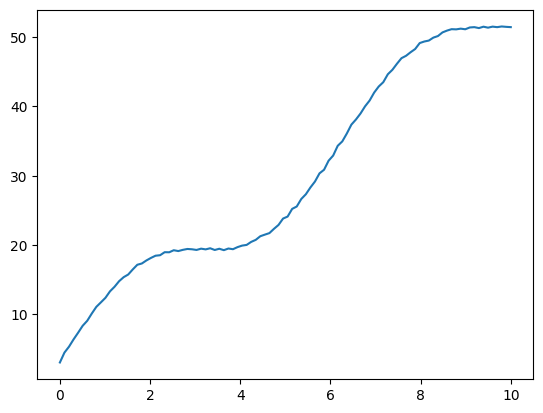

In [ ]:
import numpy as np
import matplotlib.pyplot as pp
x=np.linspace(0,10,100)
print(x.shape)
x=np.expand_dims(x,axis=1)
y=5.1*x[:,0]+5*np.sin(x[:,0])+3+np.random.rand(100)*0.5
X=np.concatenate([x, np.sin(x), np.cos(x)], axis=-1)
print(X.shape)
pp.plot(x, y)

In [ ]:
from sklearn.linear_model import LinearRegression
clf = LinearRegression()
clf.fit(X, y)
print(clf.score(X, y))
print(clf.coef_, clf.intercept_)

0.9999182592537891
[ 5.09607241  5.01026597 -0.04122336] 3.2831358770244066


0.9997627428439816
[-0.68987991  0.50128632  1.1873274 ] 0.07707497239525907


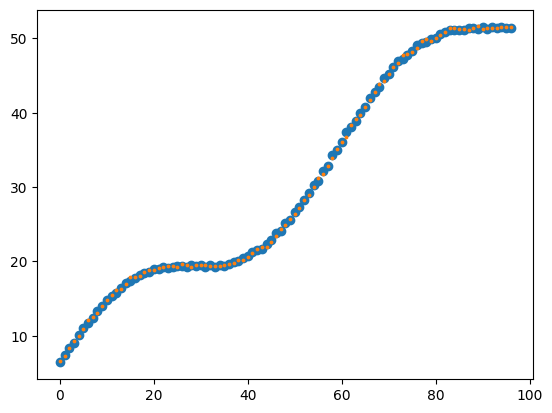

In [ ]:
X = np.concatenate([np.expand_dims(y[:-3], axis=1), np.expand_dims(y[1:-2], axis=1), np.expand_dims(y[2:-1], axis=1)], axis=1)
Y=y[3:]


clf = LinearRegression()
clf.fit(X, Y)
print(clf.score(X, Y))
print(clf.coef_, clf.intercept_)
plt.scatter(range(Y.shape[0]), Y)
plt.scatter(range(Y.shape[0]), clf.predict(X), s=3)

0.8544131007796923
[-0.69240361  0.54763447  1.14693262] 0.030855509425411043


(77.0, 97.0)

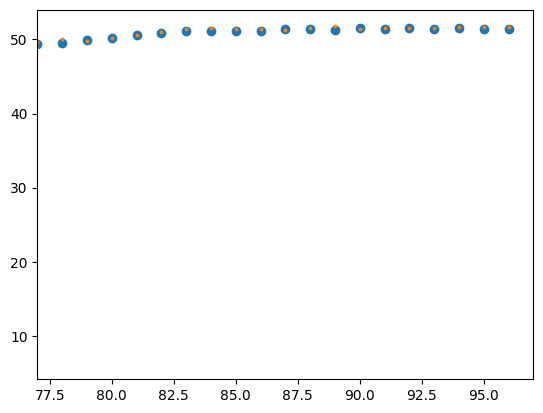

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

clf = LinearRegression()
d=X.shape[0]*4//5
clf.fit(X[:d], Y[:d])
print(clf.score(X[d:], Y[d:]))
print(clf.coef_, clf.intercept_)
plt.scatter(range(Y.shape[0]), Y)
plt.scatter(range(Y.shape[0]), clf.predict(X), s=3)
plt.xlim(d, X.shape[0])

14.11.2025

Авторегрессия

-24.824412423194392


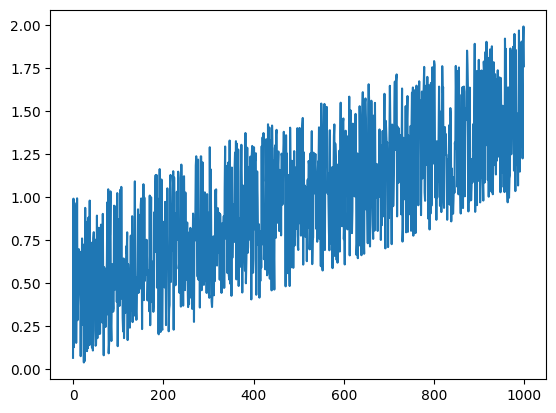

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


x = np.random.rand(1000)+np.array(range(1000))*0.001
plt.plot(x)
index=x.shape[0] // 2
x1 = x[:index]
x2 = x[index:]
m1 = x1.mean()
m2 = x2.mean()
s1 = x1.std()
s2 = x2.std()

T = (m1 - m2) / np.sqrt(s1**2/index+s2**2/index)
print(T)

Преобразование Бокса-Кокса

-20.949152593585275


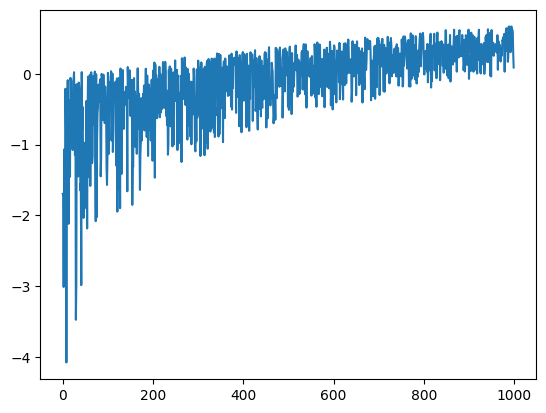

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


x = np.random.rand(1000)+np.array(range(1000))*0.001
x=np.log(x+1e-3)
plt.plot(x)
index=x.shape[0] // 2
x1 = x[:index]
x2 = x[index:]
m1 = x1.mean()
m2 = x2.mean()
s1 = x1.std()
s2 = x2.std()

T = (m1 - m2) / np.sqrt(s1**2/index+s2**2/index)
print(T)

-21.947524999018327


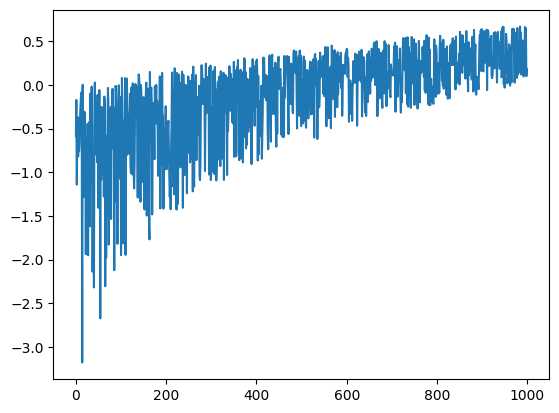

In [ ]:
import scipy.stats as ss
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


x = np.random.rand(1000)+np.array(range(1000))*0.001
x=ss.boxcox(x, lmbda=0)
plt.plot(x)
index=x.shape[0] // 2
x1 = x[:index]
x2 = x[index:]
m1 = x1.mean()
m2 = x2.mean()
s1 = x1.std()
s2 = x2.std()

T = (m1 - m2) / np.sqrt(s1**2/index+s2**2/index)
print(T)

Дифференцирование

-0.06947925187883801


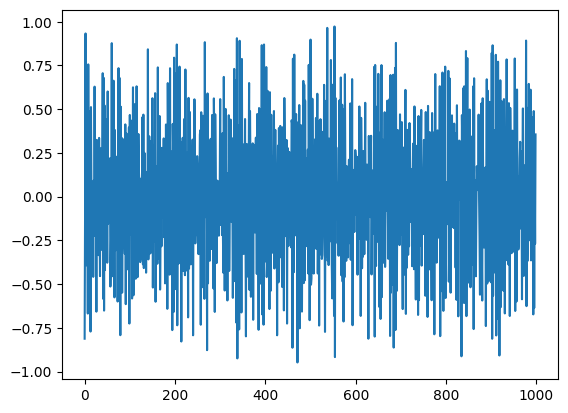

In [ ]:
import scipy.stats as ss
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

x = np.random.rand(1000)+np.array(range(1000))*0.001
x=x[1:]-x[:-1]
plt.plot(x)
index=x.shape[0] // 2
x1 = x[:index]
x2 = x[index:]
m1 = x1.mean()
m2 = x2.mean()
s1 = x1.std()
s2 = x2.std()

T = (m1 - m2) / np.sqrt(s1**2/index+s2**2/index)
print(T)

Усреднение

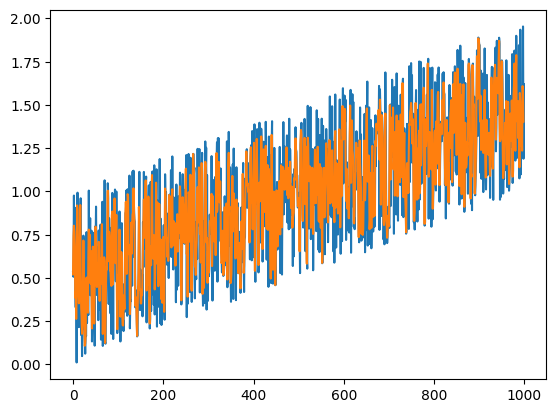

In [ ]:
x = np.random.rand(1000)+np.array(range(1000))*0.001
A, B = 0.5, 0.5
y=A*x[1:] + B*x[:-1]
plt.plot(x)
plt.plot(y)

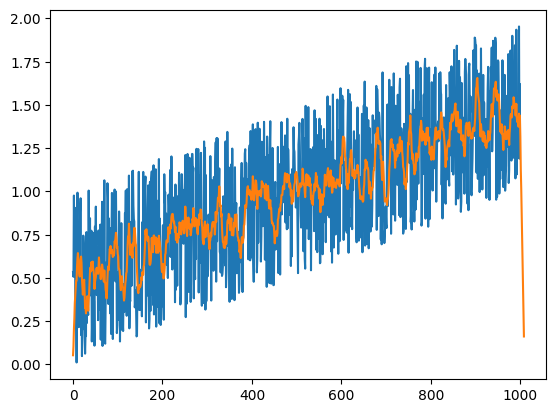

In [ ]:
y=np.convolve(x, [0.1]*10)
plt.plot(x)
plt.plot(y)

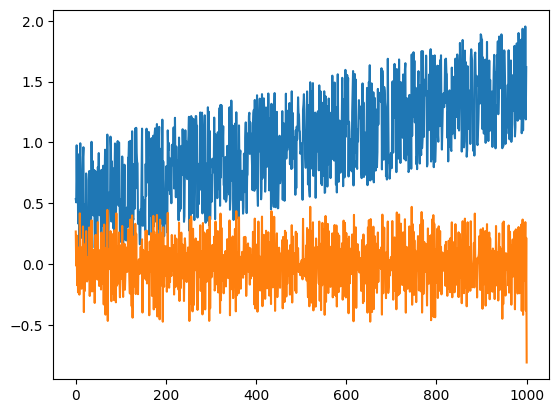

In [ ]:
y=np.convolve(x, [0.5, -0.5])
plt.plot(x)
plt.plot(y)

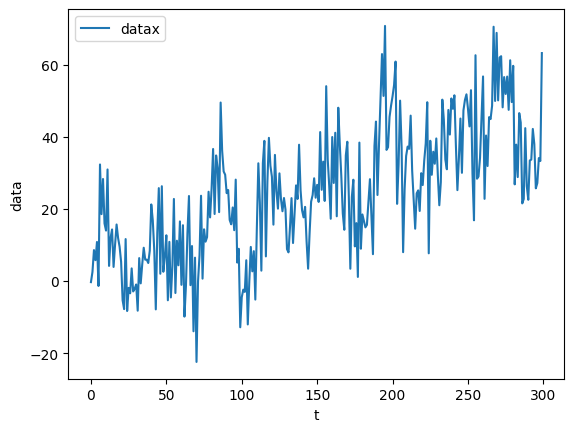

In [ ]:
import numpy as np
t=np.linspace(0,100,300)
zx=np.sin(t/2)*10*(1+np.cos(t/5.1))
zy=np.cos(t/2)*10*(1+np.cos(t/5.1))
ty=t*0.5
err=10*ss.norm().rvs(t.shape[0])

datax=zx+ty+err
datay=zy+err
plt.plot(datax,label='datax')
# pp.plot(datay,label='datay')
plt.xlabel('t')
plt.ylabel('data')
plt.legend();

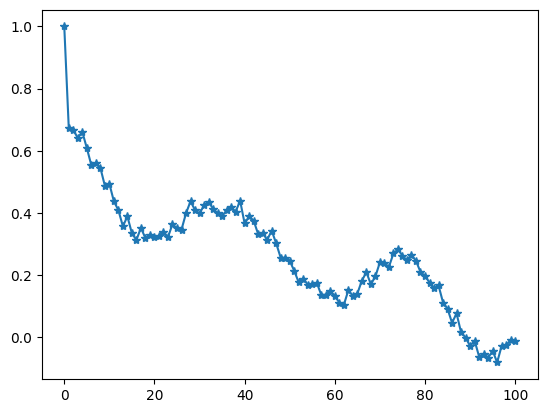

In [ ]:
from statsmodels.tsa.stattools import acf
bd = acf(datax, nlags=100)
plt.plot(bd, '-*')

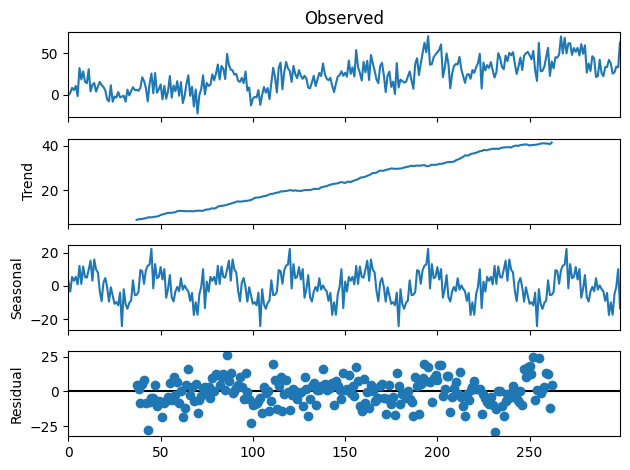

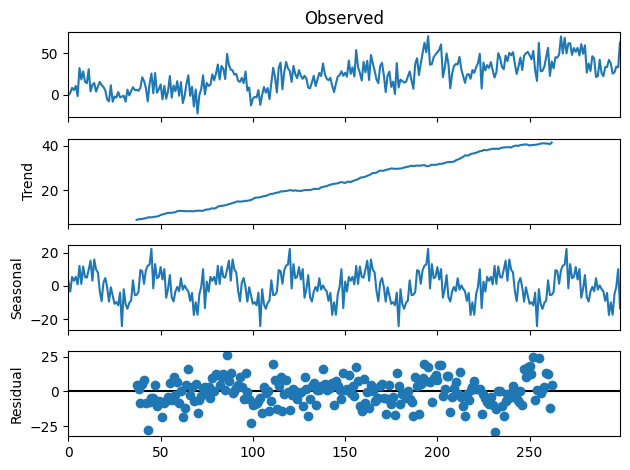

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
seasonal_decompose(datax[:], period=75).plot()

-14.59986688235981


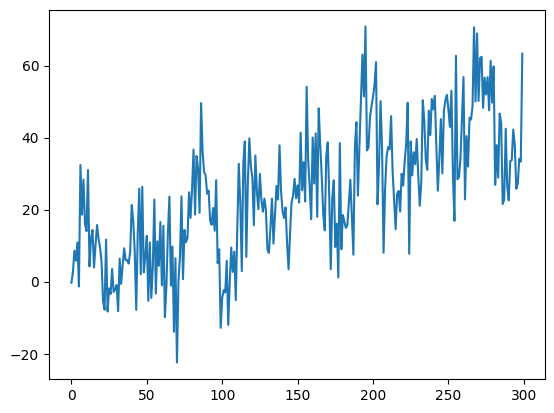

In [ ]:
index=datax.shape[0] // 2
x1 = datax[:index]
x2 = datax[index:]
m1 = x1.mean()
m2 = x2.mean()
s1 = x1.std()
s2 = x2.std()

T = (m1 - m2) / np.sqrt(s1**2/index+s2**2/index)
print(T)

15.11.2025

Критерий от Фулера. Проверяет наличие тренда.

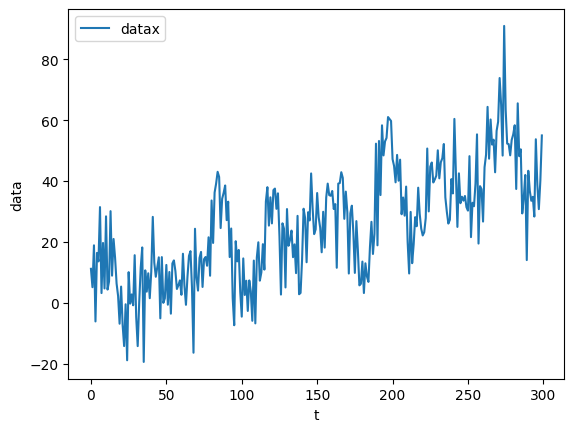

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
t=np.linspace(0,100,300)
zx=np.sin(t/2)*10*(1+np.cos(t/5.1))
zy=np.cos(t/2)*10*(1+np.cos(t/5.1))
ty=t*0.5
err=10*ss.norm().rvs(t.shape[0])

datax=zx+ty+err
datay=zy+err
plt.plot(datax,label='datax')
plt.xlabel('t')
plt.ylabel('data')
plt.legend();

ADF statistics: -2.528808
p-value: 0.108621
Critical Vallues:
	1%: -3.453
	5%: -2.871
	10%: -2.572
Ряд стационарен


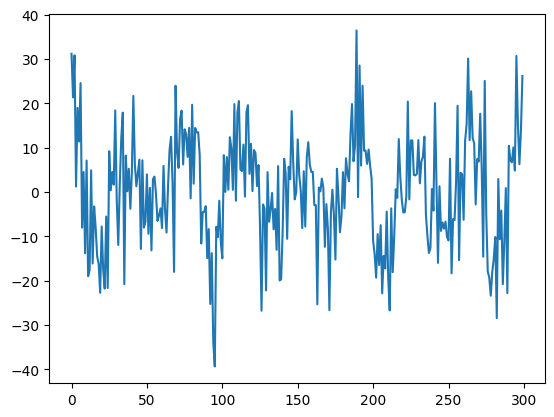

In [ ]:
from statsmodels.tsa.stattools import adfuller
X = datax
result = adfuller(X)
print("ADF statistics: %f" % result[0])
print("p-value: %f" % result[1])
print("Critical Vallues:")
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))
print("Ряд стационарен")
plt.plot(datay)

ADF statistics: 1.042624
p-value: 0.994696
Critical Vallues:
	1%: -3.453
	5%: -2.872
	10%: -2.572
Ряд стационарен


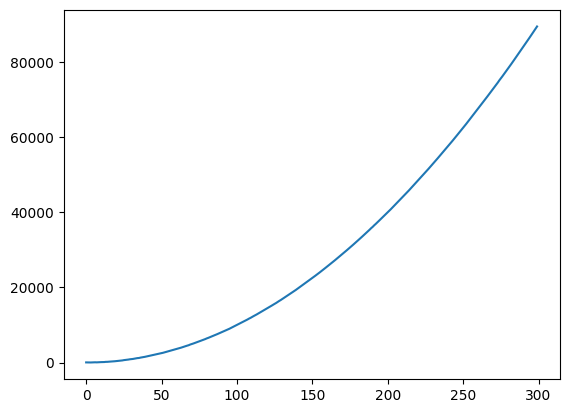

In [ ]:
from statsmodels.tsa.stattools import adfuller
X = datay + np.array(range(datay.shape[0])) ** 2
result = adfuller(X)
print("ADF statistics: %f" % result[0])
print("p-value: %f" % result[1])
print("Critical Vallues:")
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))
print("Ряд стационарен")
plt.plot(X)

ADF statistics: -3.624698
p-value: 0.005306
Critical Vallues:
	1%: -3.453
	5%: -2.872
	10%: -2.572
Ряд стационарен


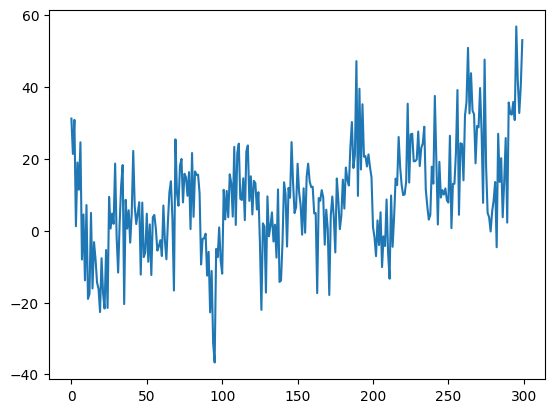

In [ ]:
from statsmodels.tsa.stattools import adfuller
X = datay + (0.0003)* np.array(range(datay.shape[0])) ** 2
result = adfuller(X)
print("ADF statistics: %f" % result[0])
print("p-value: %f" % result[1])
print("Critical Vallues:")
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))
print("Ряд стационарен")
plt.plot(X)

AR model params: [ 25.48908879   0.72362872 164.95114777]
RMSE: 12.857723262863455


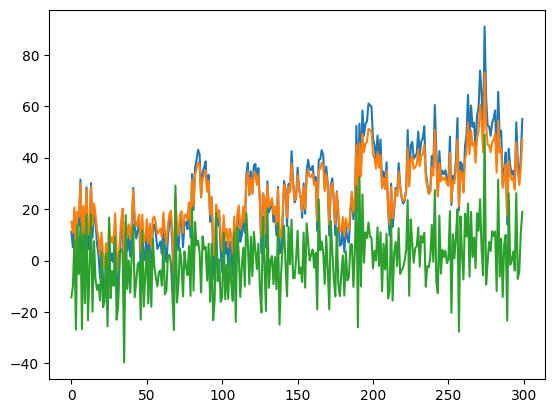

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
ar = ARIMA(datax, order=(1, 0, 0)).fit()
print("AR model params:", ar.params)
S = ar.predict(1, datax.shape[0])
plt.plot(datax)
plt.plot(S)
print(ar)
plt.plot(ar.resid)
print("RMSE:", np.sqrt((ar.resid ** 2).mean()))

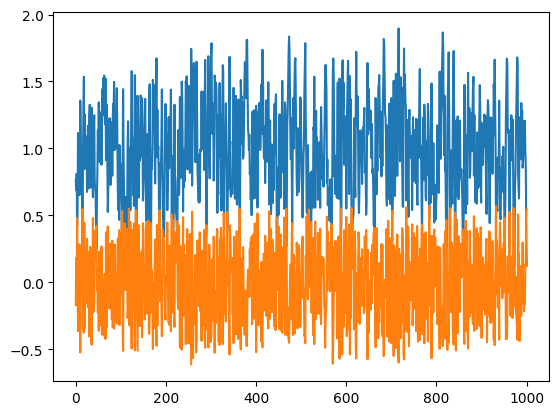

In [ ]:
er = np.random.rand(1000)
er = np.convolve(er, [1,0.7,0.3])
from sklearn.linear_model import LinearRegression
clf = LinearRegression()
X = er[:-1]
Y = er[1:]
clf.fit(X[:, np.newaxis], Y)
plt.plot(Y)
plt.plot(clf.predict(X[:, np.newaxis]) - Y)

In [ ]:
r, pv = ss.pearsonr(X, Y)
print(pv)
if pv < 0.05:
  print("Correlate")
else:
  print("Not correlate")

4.9742391789347005e-79
Correlate


Прогноз среднего

AR model params: [ -0.23518674  -0.5102116  120.41303244]
RMSE: 10.980208308170065


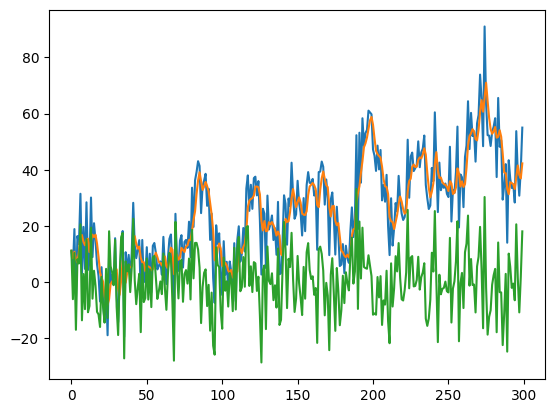

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
ar = ARIMA(datax, order=(1, 0, 1)).fit()
print("AR model params:", ar.params)
S = ar.predict(1, datax.shape[0])
plt.plot(datax)
plt.plot(S)
print(ar)
plt.plot(ar.resid)
print("RMSE:", np.sqrt((ar.resid ** 2).mean()))

AR model params: [ 25.65505175   0.96736084  -0.62268797 121.73786408]
RMSE: 11.060559420926635


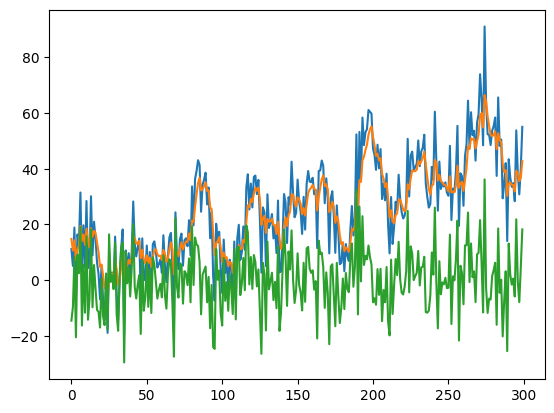

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
ar = ARIMA(datax, order=(1, 0, 1)).fit()
print("AR model params:", ar.params)
S = ar.predict(1, datax.shape[0])
plt.plot(datax)
plt.plot(S)
print(ar)
plt.plot(ar.resid)
print("RMSE:", np.sqrt((ar.resid ** 2).mean()))

AR model params: [ 25.38455335   1.20618298  -0.241379    -0.98103107   0.33949862
 117.38989038]
RMSE: 10.86129124770882


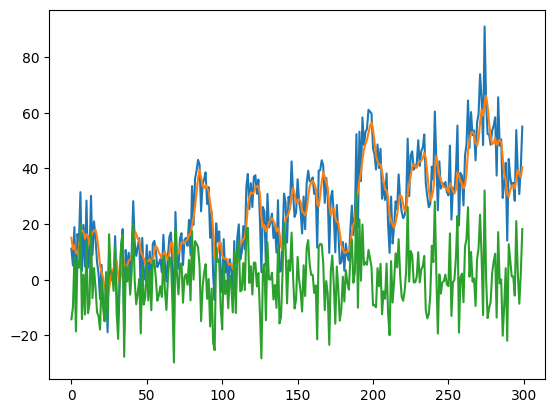

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
ar = ARIMA(datax, order=(2, 0, 2)).fit()
print("AR model params:", ar.params)
S = ar.predict(1, datax.shape[0])
plt.plot(datax)
plt.plot(S)
print(ar)
plt.plot(ar.resid)
print("RMSE:", np.sqrt((ar.resid ** 2).mean()))

AR model params: [ -0.23518674  -0.5102116  120.41303244]
RMSE: 10.980208308170065


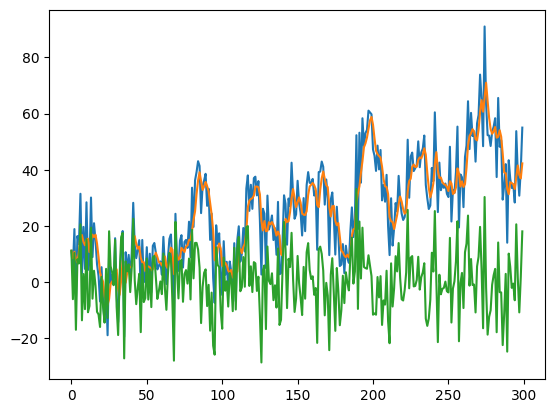

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
ar = ARIMA(datax, order=(1, 1, 1)).fit()
print("AR model params:", ar.params)
S = ar.predict(1, datax.shape[0])
plt.plot(datax)
plt.plot(S)
print(ar)
plt.plot(ar.resid)
print("RMSE:", np.sqrt((ar.resid ** 2).mean()))

Парамет p - это время коррелиации

Параметр q - частичная автокоррелиация

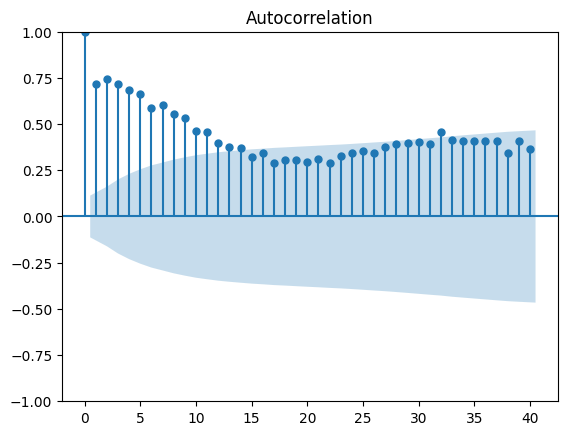

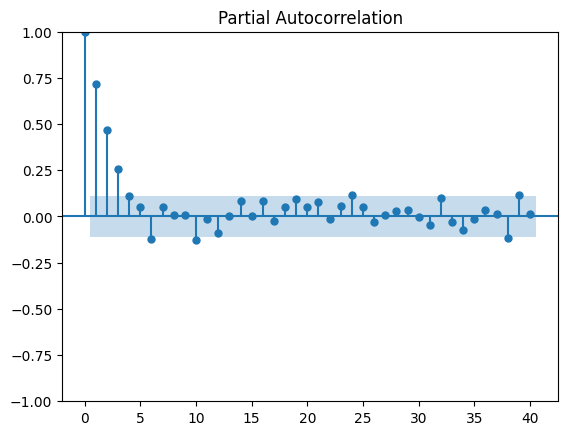

In [ ]:
import statsmodels.api as st
st.graphics.tsa.plot_acf(datax, lags=40);
st.graphics.tsa.plot_pacf(datax, lags=40);

AR model params: [-7.20731461e-01 -4.56199059e-01 -3.56235091e-01  4.74614415e-01
  4.66782362e-01  1.63127036e-01  1.21072035e-01  1.05214897e-01
  8.57709691e-02  8.34487889e-02  1.57231199e-02 -1.75857384e-01
 -2.57615441e-01 -1.82180586e-01 -2.55700058e-01 -1.16499181e-01
 -1.26129774e-01 -1.94286056e-01 -6.25384416e-02 -1.07494308e-01
  2.84707705e-02  8.41638026e-02 -7.38334401e-01  1.02328754e+02]
RMSE: 10.152268386120676


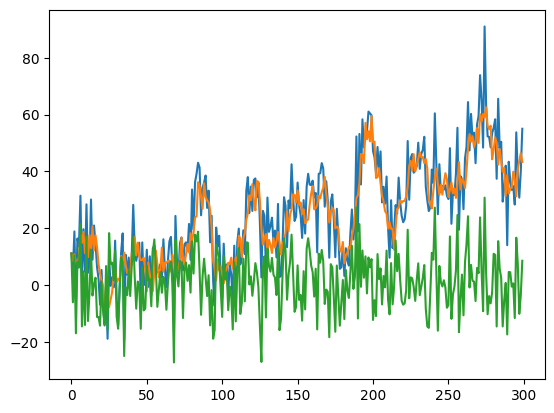

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
ar = ARIMA(datax, order=(19, 1, 4)).fit()
print("AR model params:", ar.params)
S = ar.predict(1, datax.shape[0])
plt.plot(datax)
plt.plot(S)
print(ar)
plt.plot(ar.resid)
print("RMSE:", np.sqrt((ar.resid ** 2).mean()))

SARIMA

In [ ]:
import statsmodels.tsa.statespace.sarimax as smtss
sarima = smtss.SARIMAX(datax, order=(19, 1, 4),seasonal_order=(1,1,1,75)).fit()
print("AR model params:",sarima.params)
S = ar.predict(1, datax.shape[0])
plt.plot(datax)
plt.plot(S)
print(ar)
plt.plot(ar.resid.std())
print("RMSE:", np.sqrt((ar.resid ** 2).std()))

 Методы спектральной оценки

In [ ]:
!pip install spectrum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.5/231.5 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.1/720.1 kB 19.9 MB/s eta 0:00:00
  Created wheel for spectrum: filename=spectrum-0.9.0-cp312-cp312-linux_x86_64.whl size=236768 sha256=69605417227d23ba7c599581d76609d1289dfc8fba6f48306105d78fe8dc1597
  Stored in directory: /root/.cache/pip/wheels/19/a0/e0/e04656d89dd723adbe6ea41ab5fe702f5d4ccf95653eb54b04
Successfully built spectrum


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


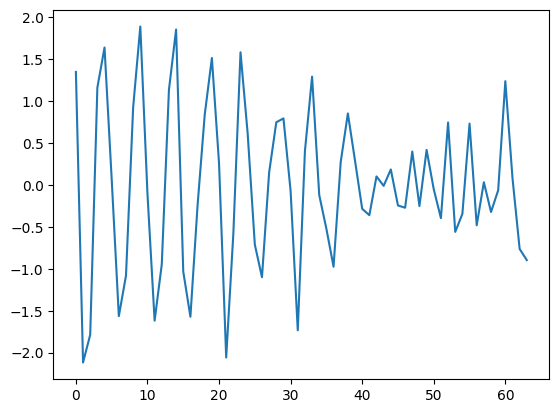

In [ ]:
import matplotlib.pyplot as pyplot
from spectrum import marple_data
data=marple_data
plt.plot(marple_data)

22.11.2025

Сжатие данных

In [ ]:
import re
f1 = open('11.txt', 'wt')
f2 = open('22.txt', 'wt')

f = open('out.dat')

for s in f:
  d = re.split(f'\t', s)
  print(d[0]+'\t', file=f1, end='')
  print(d[1], file=f2, end='')
f1.close()
f2.close()
!ls -l *.txt *.dat

-rw-r--r-- 1 root root 168889 Nov 22 02:33 11.txt
-rw-r--r-- 1 root root  48890 Nov 22 02:33 22.txt
-rw-r--r-- 1 root root 217779 Nov 22 02:29 out.dat


In [ ]:
!xz -9 11.txt
!xz -9 22.txt
!ls -l *.xz

-rw-r--r-- 1 root root 78532 Nov 22 02:33 11.txt.xz
-rw-r--r-- 1 root root  3224 Nov 22 02:33 22.txt.xz


Преобразование хара

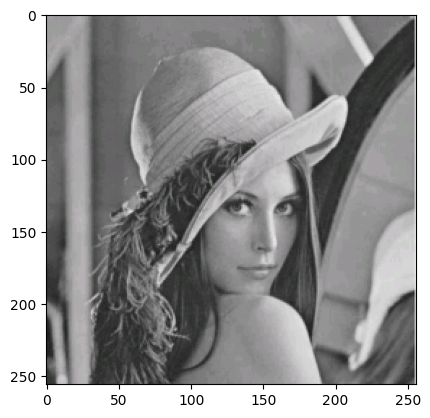

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as npimg

import numpy as np
img = npimg.imread('LenaImage.png')
imgplot = plt.imshow(img)

In [ ]:
gs_img = img[:, :, 0]
gs_img1D = np.reshape(gs_img, gs_img.shape[0] * gs_img.shape[1])
gs_img1D.shape

(65536,)

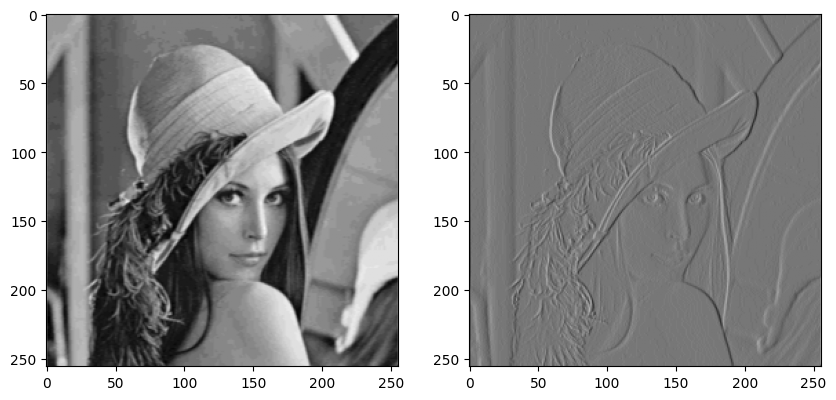

In [ ]:
import numpy as np
from math import sqrt
gs_img1D_padded = gs_img1D[:-1]
slow = np.convolve(gs_img1D_padded, [1/sqrt(2), 1/sqrt(2)])
fast = np.convolve(gs_img1D_padded, [1/sqrt(2), -1/sqrt(2)])
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(slow.reshape(256, 256), cmap='gray')
axs[1].imshow(fast.reshape(256, 256), cmap='gray')

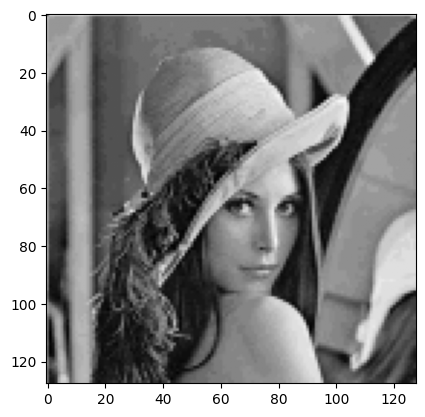

In [ ]:
plt.imshow(slow.reshape(256, 256)[::2, ::2], cmap='gray')

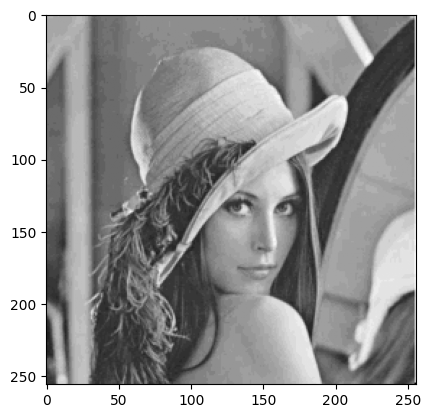

In [ ]:
plt.imshow((slow+fast).reshape(256, 256), cmap='gray')

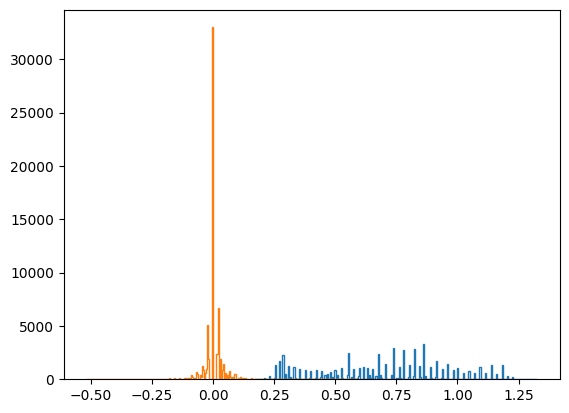

In [ ]:
plt.hist(slow, histtype='step', bins=256)
plt.hist(fast, histtype='step', bins=256);

Преобразование Уолша

In [ ]:
!pip install sympy

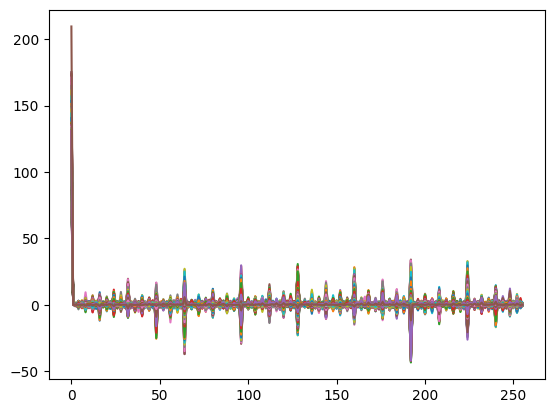

In [ ]:
from sympy import fwht, ifwht
spec = fwht(gs_img)
plt.plot(spec)

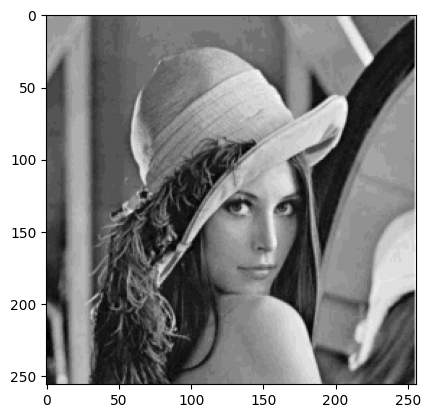

In [ ]:
r = np.array(ifwht(spec))
img = r.reshape(256, 256)
img = img.astype('float')
plt.imshow(img, cmap='gray')

0.9432220458984375


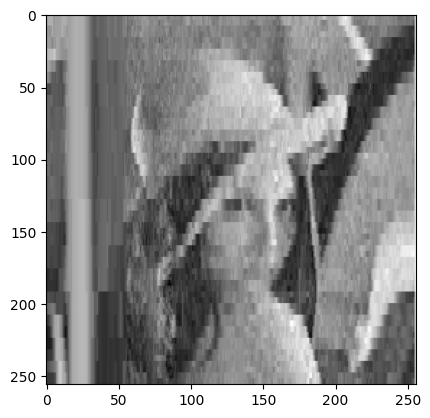

In [ ]:
ff = np.array(spec)
print((np.abs(ff) < 4).astype(int).sum() / (ff.shape[0] * ff.shape[1]))

ff[np.abs(ff) < 4]=0
fil=np.array(ifwht(ff)).astype('float')
img = fil.reshape(256, 256)
plt.imshow(img, cmap='gray')

0.7246551513671875


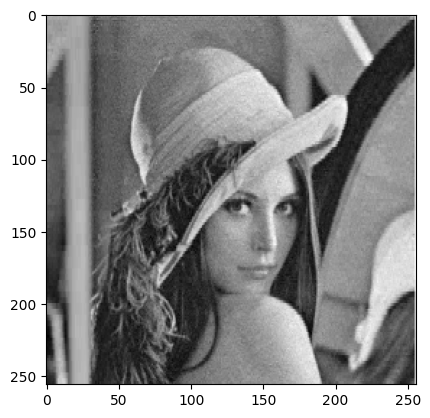

In [ ]:
ff = np.array(spec)
print((np.abs(ff) < 1).astype(int).sum() / (ff.shape[0] * ff.shape[1]))

ff[np.abs(ff) < 1]=0
fil=np.array(ifwht(ff)).astype('float')
img = fil.reshape(256, 256)
plt.imshow(img, cmap='gray')

Преобразование Фурье

In [ ]:
from scipy.fft import fft, ifft
gs_img1D = np.reshape(gs_img, gs_img.shape[0] * gs_img.shape[1])
print(gs_img1D)

[0.8352941  0.8352941  0.8352941  ... 0.39215687 0.39215687 0.77254903]


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


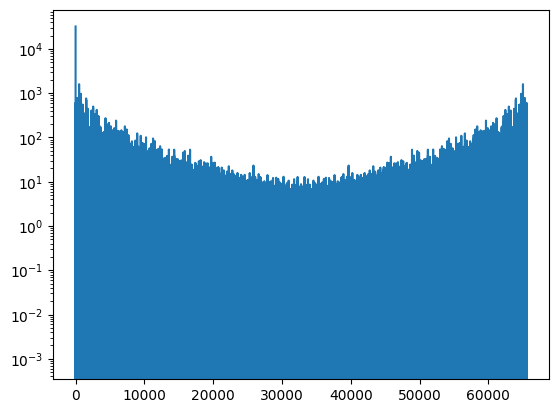

In [ ]:
f_img1D = fft(gs_img1D)
plt.plot(f_img1D)
plt.yscale('log')

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


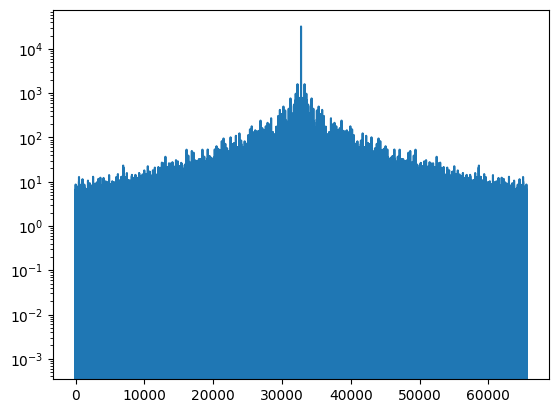

In [ ]:
from scipy.fft import fftshift
plt.plot(fftshift(f_img1D))
plt.yscale('log')

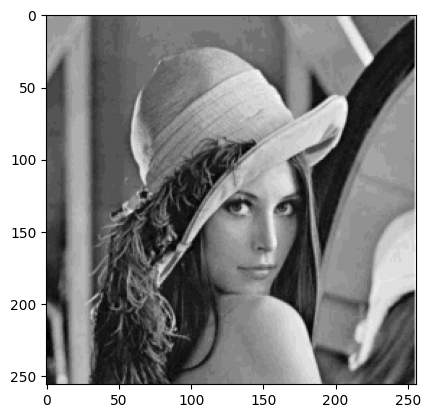

In [ ]:
img = np.real(ifft(f_img1D).reshape(256, 256))
plt.imshow(img, cmap='gray')

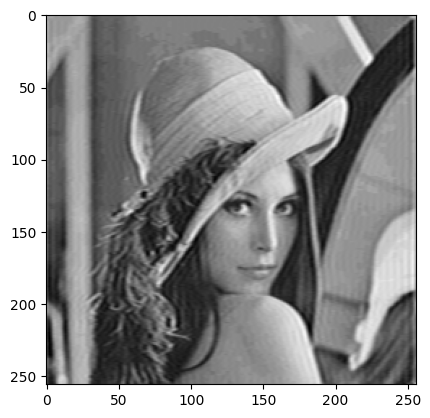

In [ ]:
ff = f_img1D.copy()
ff[round(ff.shape[0] *0.2):round(ff.shape[0] * 0.8)] = 0
fil=ifft(ff)
img = np.real(fil.reshape(256, 256))
plt.imshow(img, cmap='gray')

Преобразование Хартли

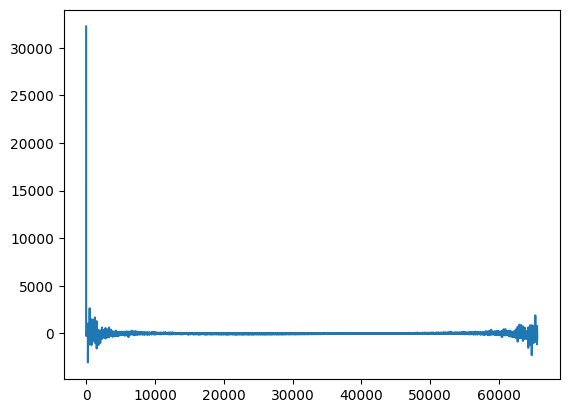

In [ ]:
def dht(x:np.array):
  X = np.fft.fft(x)
  X = np.real(X) - np.imag(X)
  return X

h_img1D = dht(gs_img1D)
plt.plot(h_img1D)

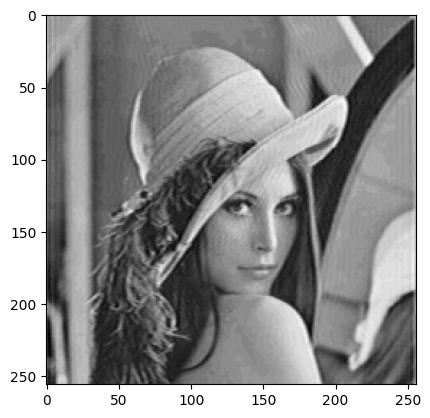

In [ ]:
ff = h_img1D.copy()
ff[round(ff.shape[0] *0.22):round(ff.shape[0] * 0.72)] = 0
fil = dht(ff)
img=fil.reshape(256, 256)
plt.imshow(img, cmap='gray')

Методы спектральной оценки

In [ ]:
!pip install spectrum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.5/231.5 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.1/720.1 kB 22.8 MB/s eta 0:00:00
  Created wheel for spectrum: filename=spectrum-0.9.0-cp312-cp312-linux_x86_64.whl size=236769 sha256=177d3506b64de7e69b3b615be86a713babf2f2926ea558925099b081a0a748d4
  Stored in directory: /root/.cache/pip/wheels/19/a0/e0/e04656d89dd723adbe6ea41ab5fe702f5d4ccf95653eb54b04
Successfully built spectrum


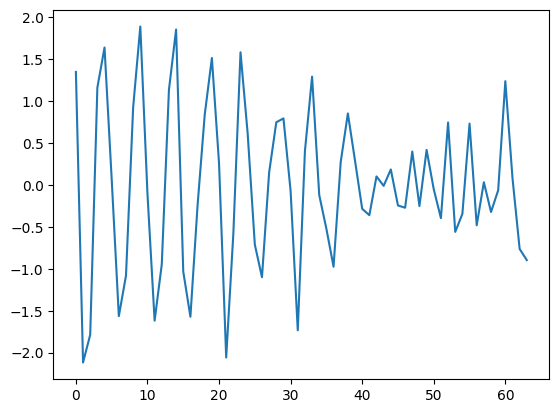

In [ ]:
import matplotlib.pyplot as pyplot
from spectrum import marple_data
data=marple_data
plt.plot(marple_data)

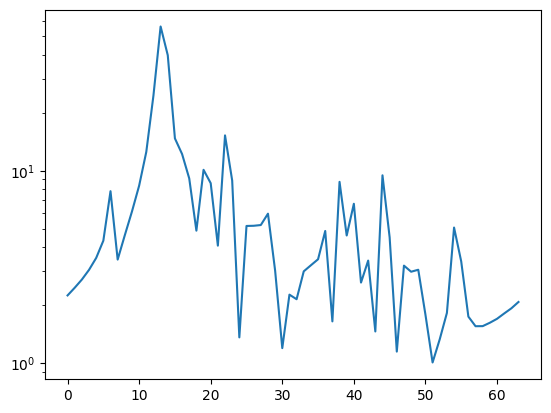

In [ ]:
ft = fft(data)
plt.yscale('log')
plt.plot(np.abs(ft))

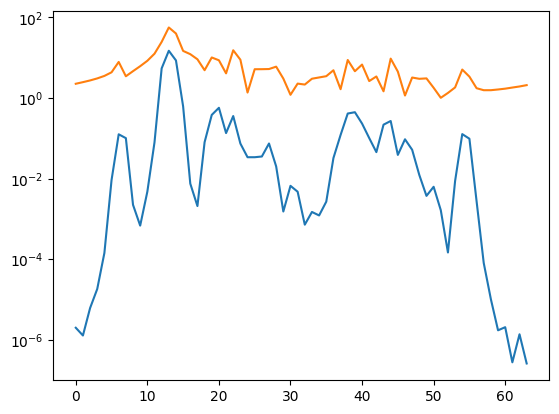

In [ ]:
from spectrum import Periodogram
pg = Periodogram(data, sampling=1024)
plt.yscale('log')
plt.plot(pg.psd)
plt.plot(np.abs(ft))

In [ ]:
print(pg.window)

hann


Window object:
Name: hann
Length: 64
NFFT (for the frequency response): 2048
ENBW=1.5238095238095237



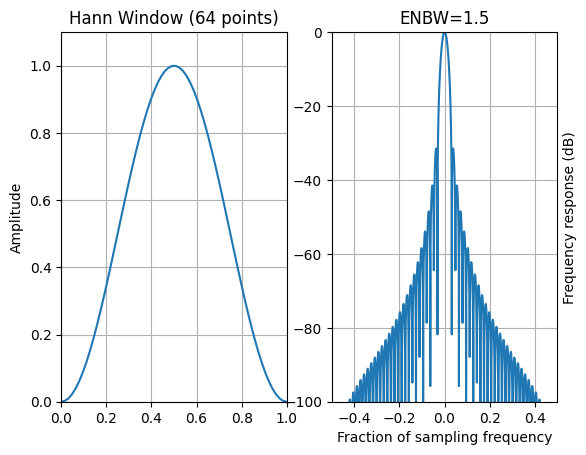

In [ ]:
from spectrum.window import Window
N = 64
w = Window(N, pg.window)
print(w)
w.plot_time_freq()

Window object:
Name: rectangular
Length: 64
NFFT (for the frequency response): 2048
ENBW=1.0



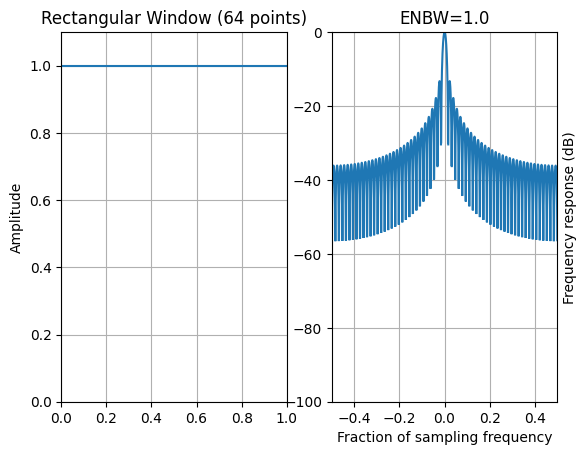

In [ ]:
pg.window = 'rectangular'
w = Window(N, pg.window)
print(w)
w.plot_time_freq()

Window object:
Name: triangular
Length: 64
NFFT (for the frequency response): 2048
ENBW=1.354838709677419



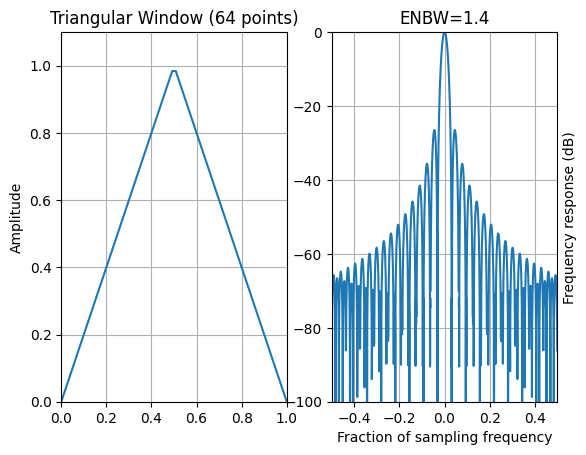

In [ ]:
pg.window = 'triangular'
w = Window(N, pg.window)
print(w)
w.plot_time_freq()

Window object:
Name: kaiser
Length: 64
NFFT (for the frequency response): 2048
ENBW=1.748556240369417



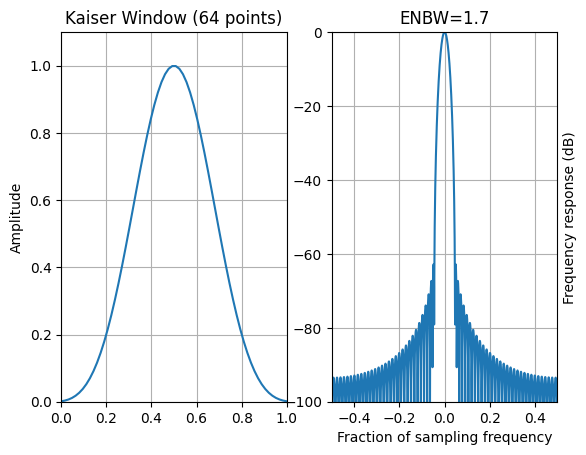

In [ ]:
pg.window = 'kaiser'
w = Window(N, pg.window)
print(w)
w.plot_time_freq()

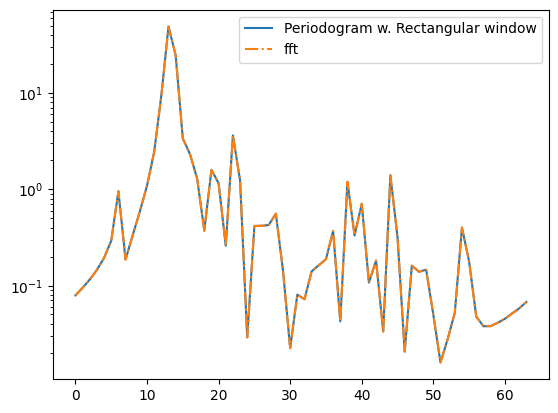

In [ ]:
pg = Periodogram(marple_data, sampling=1024)
ft=np.abs(fft(marple_data))
pg.window='rectangular'
pyplot.yscale('log')
pyplot.plot(pg.psd,label='Periodogram w. Rectangular window')
pyplot.plot(np.abs(ft)**2/N,'-.',label='fft')
pyplot.legend()

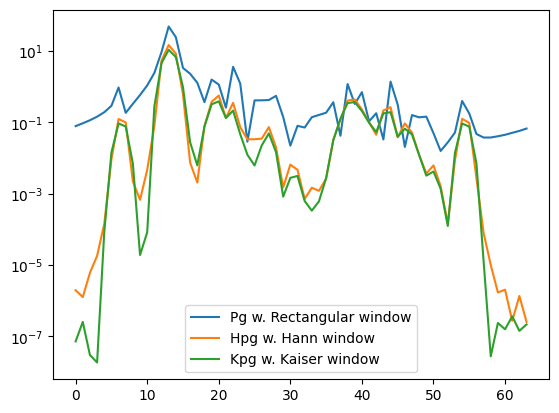

In [ ]:
pg = Periodogram(marple_data, sampling=1024)
pg.window='rectangular'
hpg = Periodogram(marple_data, sampling=1024)
hpg.window='hann'
kpg = Periodogram(marple_data, sampling=1024)
kpg.window='kaiser'

plt.yscale('log')
plt.plot(pg.psd, label='Pg w. Rectangular window')
plt.plot(hpg.psd, label = 'Hpg w. Hann window')
plt.plot(kpg.psd, label = 'Kpg w. Kaiser window')
plt.legend()

Теорема Винера-Хинчина

Параметрическое оценивание

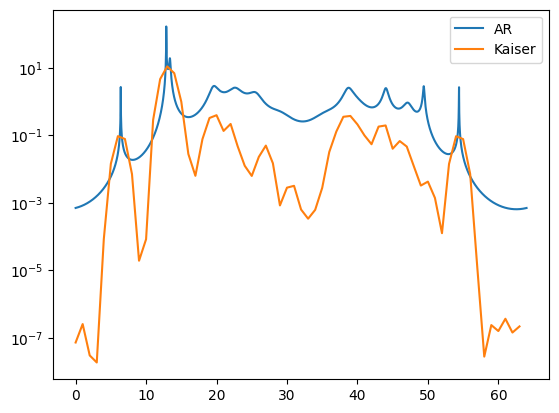

In [ ]:
from spectrum import arcovar, marple_data, arma2psd
N = 64
kpg = Periodogram(marple_data, sampling=1024)
kpg.window = 'kaiser'

ar_values, error = arcovar(marple_data, 15)
psd = arma2psd(ar_values)
plt.yscale('log')
plt.plot(np.linspace(0, N, len(psd)), np.sqrt(psd/N), label='AR')
plt.plot(kpg.psd, label='Kaiser')
plt.legend()

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


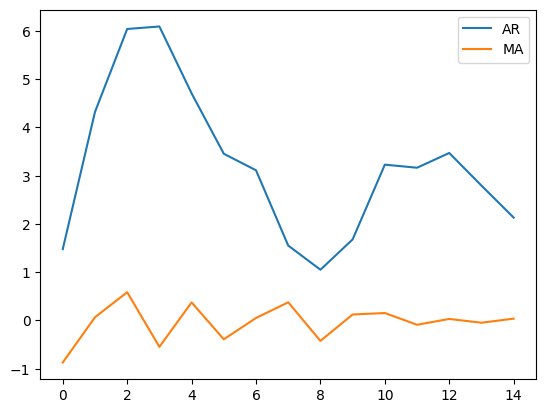

In [ ]:
from spectrum import arma_estimate

a, b,rho = arma_estimate(marple_data, 15, 15, 30)
plt.plot(a, label='AR')
plt.plot(b, label ='MA')
plt.legend()

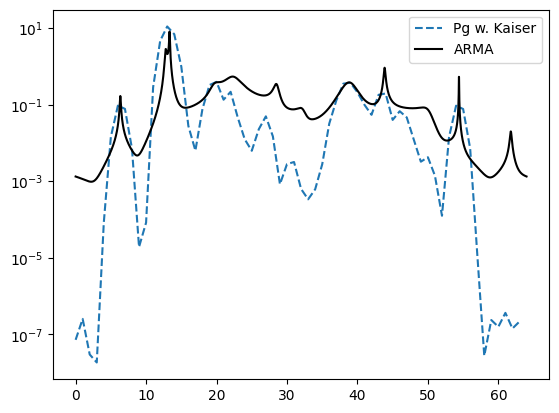

In [ ]:
psd = arma2psd(A=a, B=b, rho=rho, norm=True)
plt.yscale('log')
plt.plot(kpg.psd, '--', label='Pg w. Kaiser')
plt.plot(np.linspace(0, N, len(psd)), np.sqrt(psd*N), label='ARMA', c='k')
plt.legend()

Спектрограммы

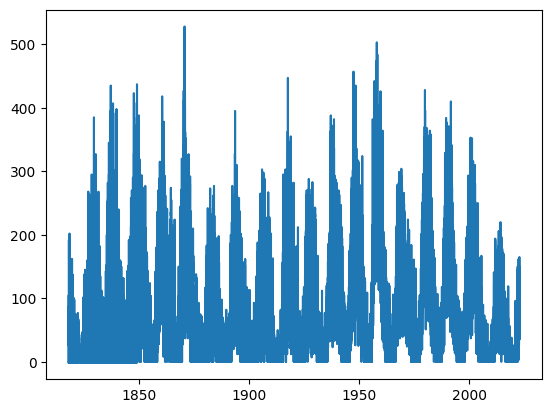

In [ ]:
from spectrum import Spectrogram, dolphin_filename, readwav
f = open('test.0.txt')
d = []
for s in f:
  s = s.replace('*', '')
  d.append([float(x) for x in s.split()])
d = np.array(d)
plt.plot(d[:, 3], d[:, 4])

Duration: 1035.0
W: 16
ws: 8
Computing 129 TFs
done


/usr/local/lib/python3.12/dist-packages/spectrum/spectrogram.py:38: RuntimeWarning: divide by zero encountered in log10
  pylab.imshow(-np.log10(self.results[self._start_y:,:]),


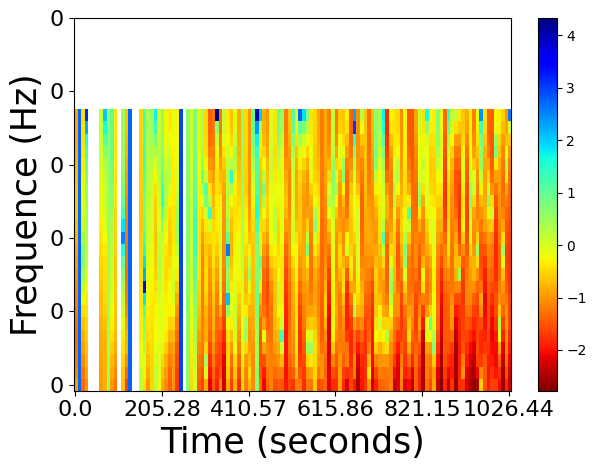

In [ ]:
samplerate = 1
p = Spectrogram(d[d[:, 3] > 2020, 4], ws=8, W=16, sampling=samplerate)
p.periodogram()
p.plot()

Duration: 7.116961451247166
W: 4096
ws: 128
Computing 1226 TFs
done


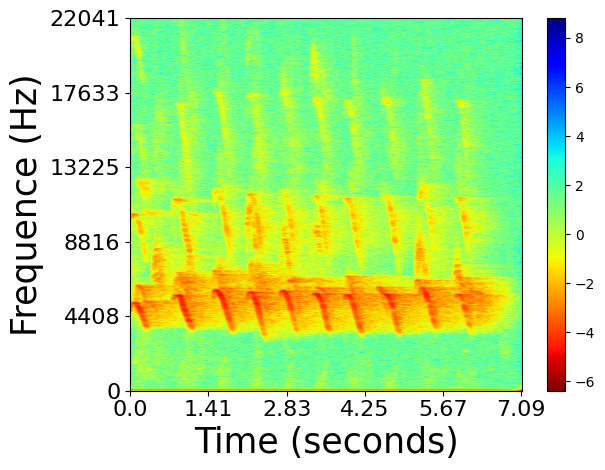

In [ ]:
data, samplerate = readwav(dolphin_filename)
p = Spectrogram(data, ws=128, W=4096, sampling=samplerate)
p.periodogram()
p.plot()

In [ ]:
!pip install playsound

  Preparing metadata (setup.py) ... done
  Created wheel for playsound: filename=playsound-1.3.0-py3-none-any.whl size=7020 sha256=e1c3915ba3b2ecd3ad4505f4ce98f6bafb8e74289cff8ffcf6ee5012018df813
  Stored in directory: /root/.cache/pip/wheels/cf/42/ff/7c587bae55eec67b909ca316b250d9b4daedbf272a3cbeb907
Successfully built playsound


In [ ]:
from IPython.display import Audio
data, samplerate = readwav(dolphin_filename)
Audio(data, rate=samplerate)

28.11.2025

Тематическое моделирование

Латентный семантический анализ (LSA)

Вероятностный латентный семантический анализ (PLSA)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
!wget -c https://www.gutenberg.org/files/2701/2701-0.txt

--2025-11-28 03:03:09--  https://www.gutenberg.org/files/2701/2701-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [ ]:
!rm -f ch*.txt
!mkdir ch
!mkdir ch/1

In [ ]:
f=open('2701-0.txt')
ch=0
fname='ch/1/ch'+str(ch)+'.txt'
fout=open(fname,"wt")
n=0
p=''
fnames,chapters=[],[]
for l in f:
  if 'CHAPTER ' in l:
    fout.close()
    if n<=10:
      import os
      os.remove(fname)
      ch-=1
    else:
      fnames.append(fname)
      chapters.append(p)
    ch+=1
    fname='ch/1/ch'+str(ch)+'.txt'
    fout=open(fname,"wt")
    n=0
    p=''
  fout.write(l)
  p+=l
  n+=1
fout.close()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline

documents = chapters
vectorized = TfidfVectorizer(stop_words='english', use_idf=True, smooth_idf=True)
s = vectorized.fit(documents[0:1])
print(s.vocabulary_)

{'start': 12, 'project': 11, 'gutenberg': 6, 'ebook': 3, '2701': 0, 'moby': 10, 'dick': 2, 'whale': 15, 'herman': 7, 'melville': 9, 'contents': 1, 'etymology': 4, 'extracts': 5, 'supplied': 14, 'sub': 13, 'librarian': 8}


In [ ]:
svd_model = TruncatedSVD(n_components=10, algorithm='randomized', n_iter=100)

svd_transformer=Pipeline([('tfidf', vectorized), ('svd', svd_model)])

vectorized.get_feature_names_out()
svd_matrix=svd_transformer.fit_transform(documents)

In [ ]:
print(svd_model.singular_values_)

[3.48516549 1.87466993 1.55354396 1.40430345 1.36302849 1.31827528
 1.26435184 1.24392707 1.23629936 1.21154871]


In [ ]:
svd_matrix.shape

(146, 10)

In [ ]:
abs(svd_matrix)

array([[0.04295228, 0.05514735, 0.0498303 , ..., 0.06605901, 0.00523285,
        0.06031364],
       [0.41858671, 0.34575355, 0.04696301, ..., 0.00831056, 0.02228233,
        0.1320983 ],
       [0.29985348, 0.02740125, 0.08769156, ..., 0.18862343, 0.04765346,
        0.06024873],
       ...,
       [0.37956504, 0.1570315 , 0.11742225, ..., 0.00792519, 0.01357699,
        0.02029982],
       [0.54659156, 0.06172376, 0.25107392, ..., 0.1436799 , 0.01467604,
        0.06674166],
       [0.56654279, 0.14809844, 0.25470688, ..., 0.09430064, 0.02090399,
        0.04206616]])

In [ ]:
t = np.argmax(abs(svd_matrix), axis=1)
(t==0).astype(int).sum()

np.int64(104)

29.11.2025

LDA (Латентное размещение Дирихле)

In [ ]:
import re
import argparse
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np

def load_documents(file_path):
    """Load documents from file, skipping first 'text' token in each line."""
    documents = []
#    with open(file_path, 'r', encoding='utf-8') as f:
    with open(file_path) as f:
        for i,line in enumerate(f):
            if not line.strip(): continue
            p,tokens = line.split('|text ')
            tokens = tokens.split()
            if len(tokens) > 1: documents.append(' '.join(tokens[1:]))
#            if i>10: break
    return documents
# print(load_documents('school.txt'))

def preprocess_text(documents):
    """Preprocess documents (convert to lowercase, remove non-alphanumeric)."""
    processed = []
    for doc in documents:
        # Keep only alphanumeric characters and spaces
        cleaned = re.sub(r'[^a-яА-Я0-9\s]', ' ', doc.lower())
        # Remove extra whitespace
        cleaned = ' '.join(cleaned.split())
        processed.append(cleaned)
    return processed

In [ ]:
documents = load_documents("school.txt")
print(len(documents))

processed_docs = preprocess_text(documents)
vectorizer = CountVectorizer(max_features=1000, lowercase=True, token_pattern=r'\b[а-яА-Я]{2,}\b')
doc_term_matrix = vectorizer.fit_transform(processed_docs)
feature_names = vectorizer.get_feature_names_out()
print(doc_term_matrix)

476
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 52226 stored elements and shape (476, 1000)>
  Coords	Values
  (0, 513)	1
  (0, 735)	8
  (0, 586)	2
  (0, 127)	4
  (0, 353)	2
  (0, 606)	3
  (0, 718)	13
  (0, 39)	5
  (0, 206)	1
  (0, 164)	7
  (0, 569)	2
  (0, 307)	5
  (0, 488)	3
  (0, 63)	2
  (0, 991)	3
  (0, 711)	2
  (0, 945)	3
  (0, 402)	1
  (0, 413)	2
  (0, 884)	1
  (0, 113)	1
  (0, 804)	3
  (0, 410)	2
  (0, 149)	1
  (0, 327)	3
  :	:
  (475, 635)	2
  (475, 840)	1
  (475, 923)	1
  (475, 919)	1
  (475, 613)	2
  (475, 759)	1
  (475, 949)	1
  (475, 715)	1
  (475, 638)	2
  (475, 790)	1
  (475, 786)	1
  (475, 975)	1
  (475, 659)	1
  (475, 749)	1
  (475, 640)	1
  (475, 475)	1
  (475, 554)	2
  (475, 989)	1
  (475, 783)	1
  (475, 705)	1
  (475, 195)	2
  (475, 993)	1
  (475, 47)	1
  (475, 716)	8
  (475, 798)	1


In [ ]:
print(feature_names)

['австралия' 'автомобиль' 'автор' 'азия' 'активно' 'активный' 'александр'
 'америка' 'анализ' 'английский' 'англия' 'антарктида' 'армия'
 'атлантический' 'атом' 'африка' 'бедный' 'без' 'берег' 'битва'
 'благодаря' 'близкий' 'блок' 'бог' 'богатый' 'более' 'больше' 'больший'
 'большинство' 'большой' 'борьба' 'брат' 'будущее' 'буква' 'бунин'
 'бывать' 'былина' 'быстро' 'быт' 'быть' 'важный' 'вводить' 'ведь' 'век'
 'вектор' 'великий' 'величина' 'вера' 'верный' 'вес' 'вести' 'весь'
 'весьма' 'вечный' 'вещество' 'вещь' 'взаимодействие' 'взгляд' 'взрослый'
 'взять' 'вид' 'видеть' 'включать' 'власть' 'влияние' 'влиять' 'вместе'
 'внешний' 'внимание' 'внутренний' 'вода' 'водный' 'военный' 'воздействие'
 'воздух' 'возможность' 'возможный' 'возникать' 'возникновение' 'возраст'
 'возрастать' 'война' 'войско' 'вокруг' 'волна' 'вопрос' 'воспитание'
 'воспринимать' 'восстание' 'восток' 'восточный' 'вот' 'впервые'
 'впоследствии' 'время' 'все' 'всегда' 'вследствие' 'встречаться'
 'вступать' 'второй' '

In [ ]:
lda = LatentDirichletAllocation(n_components=10, max_iter=100, random_state=42, n_jobs=-1)
doc_topic_distribution = lda.fit_transform(doc_term_matrix)

for topic_idx, topic in enumerate(lda.components_):
  top_words_idx = topic.argsort()[-10:][::-1]  # Top 10 words
  top_words = [feature_names[i] for i in top_words_idx]
  print("Topic ",{topic_idx + 1})
  print(" ".join(top_words) + "")

Topic  {1}
быть сила тело это что энергия этот при ток который
Topic  {2}
который территория страна этот являться население земля часть северный африка
Topic  {3}
функция точка быть промежуток при график если этот значение для
Topic  {4}
быть который они свой ребенок что человек древний дом как
Topic  {5}
выражение коэффициент квадрат многочлен сумма наречие способ разность равнина гора
Topic  {6}
быть год который государство становиться война век что свой первый
Topic  {7}
слово предложение ядро например что язык который быть это атом
Topic  {8}
который человек общество социальный это как себя развитие право являться
Topic  {9}
число уравнение корень квадратный быть дробь получать степень что решение
Topic  {10}
что который свой человек его это герой жизнь этот быть


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.8 MB/s eta 0:00:00


In [ ]:
import gensim
import gensim.corpora as corpora
doc_parsed=[x.split() for x in documents]
print(doc_parsed[:4]) #it will print the lemmatized data.
id2word = corpora.Dictionary(doc_parsed)
texts = doc_parsed
corpus = [id2word.doc2bow(text) for text in texts]
print(corpus[:4])

[['отношение', 'федерализм', 'россия', 'гг', 'после', 'президентский', 'выборы', 'год', 'между', 'правительство', 'автономный', 'республика', 'россия', 'новоизбранный', 'президент', 'ельцин', 'быть', 'заключать', 'договор', 'положение', 'который', 'распределяться', 'полномочие', 'орган', 'власть', 'этот', 'республика', 'регион', 'центр', 'после', 'распад', 'СССРВ', 'гг', 'народ', 'автономный', 'республика', 'начинать', 'требовать', 'немедленный', 'выход', 'состав', 'россия', 'принятие', 'независимость', 'национальный', 'движение', 'активизироваться', 'башкирия', 'татария', 'якутия', 'лидер', 'чечня', 'начинать', 'формировать', 'собственный', 'военный', 'база', 'создавать', 'свой', 'вооруженный', 'сила', 'который', 'должный', 'бить', 'быть', 'направлять', 'против', 'россия', 'ход', 'борьба', 'независимость', 'республика', 'частично', 'ликвидировать', 'подобный', 'сепаратистский', 'вспышка', 'смочь', 'федеративный', 'договор', 'который', 'делегировать', 'большинство', 'полномочие', 'наци

In [ ]:
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus, id2word=id2word, num_topics=10, random_state=100, update_every=1, chunksize=100, passes=10, alpha="auto", per_word_topics=True)

In [ ]:
lda_model.print_topics(10)

[(0,
  '0.025*"быть" + 0.021*"государство" + 0.017*"который" + 0.013*"страна" + 0.012*"год" + 0.008*"население" + 0.008*"первый" + 0.008*"становиться" + 0.007*"территория" + 0.007*"период"'),
 (1,
  '0.030*"предложение" + 0.027*"функция" + 0.024*"слово" + 0.016*"например" + 0.016*"f" + 0.009*"n" + 0.009*"точка" + 0.009*"существительное" + 0.008*"форма" + 0.008*"речь"'),
 (2,
  '0.012*"вода" + 0.009*"этот" + 0.009*"территория" + 0.009*"океан" + 0.008*"часть" + 0.007*"температура" + 0.007*"являться" + 0.007*"звук" + 0.007*"северный" + 0.007*"природный"'),
 (3,
  '0.019*"который" + 0.016*"что" + 0.015*"человек" + 0.013*"быть" + 0.012*"это" + 0.012*"свой" + 0.012*"его" + 0.010*"как" + 0.009*"жизнь" + 0.009*"этот"'),
 (4,
  '0.022*"пушкин" + 0.019*"свой" + 0.017*"поэт" + 0.014*"стихотворение" + 0.010*"который" + 0.010*"что" + 0.009*"любовь" + 0.009*"рассказ" + 0.007*"она" + 0.006*"лирика"'),
 (5,
  '0.018*"который" + 0.013*"человек" + 0.011*"это" + 0.009*"как" + 0.009*"социальный" + 0.009*"

In [ ]:
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus, id2word=id2word, num_topics=10, random_state=100, update_every=1, chunksize=100, passes=10, alpha=[0.1]*10, per_word_topics=True)

In [ ]:
lda_model.print_topics(10)

[(0,
  '0.025*"быть" + 0.020*"государство" + 0.017*"который" + 0.013*"страна" + 0.012*"год" + 0.008*"население" + 0.008*"первый" + 0.007*"становиться" + 0.007*"территория" + 0.007*"период"'),
 (1,
  '0.030*"предложение" + 0.027*"функция" + 0.025*"слово" + 0.016*"например" + 0.016*"f" + 0.009*"n" + 0.009*"точка" + 0.009*"существительное" + 0.009*"форма" + 0.008*"речь"'),
 (2,
  '0.012*"вода" + 0.009*"этот" + 0.009*"территория" + 0.009*"океан" + 0.008*"часть" + 0.007*"температура" + 0.007*"являться" + 0.007*"звук" + 0.007*"северный" + 0.007*"природный"'),
 (3,
  '0.018*"который" + 0.016*"что" + 0.015*"человек" + 0.013*"быть" + 0.012*"это" + 0.012*"его" + 0.012*"свой" + 0.010*"как" + 0.009*"жизнь" + 0.009*"этот"'),
 (4,
  '0.022*"пушкин" + 0.020*"свой" + 0.017*"поэт" + 0.014*"стихотворение" + 0.011*"который" + 0.010*"что" + 0.009*"любовь" + 0.009*"рассказ" + 0.007*"она" + 0.006*"год"'),
 (5,
  '0.018*"который" + 0.013*"человек" + 0.011*"это" + 0.009*"как" + 0.009*"социальный" + 0.009*"так

Норма Фробениуса

12.12.2025

Отток (Churn)

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
data=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
count = 0
for col in data.columns:
  len1 = len(set(data[col]))
  if(len1 / data.shape[0] < 0.01):
    print(col, len1, data.shape[0], len1/data.shape[0])
    count += 1
print(count)

Attrition 2 1470 0.0013605442176870747
BusinessTravel 3 1470 0.0020408163265306124
Department 3 1470 0.0020408163265306124
Education 5 1470 0.003401360544217687
EducationField 6 1470 0.004081632653061225
EmployeeCount 1 1470 0.0006802721088435374
EnvironmentSatisfaction 4 1470 0.0027210884353741495
Gender 2 1470 0.0013605442176870747
JobInvolvement 4 1470 0.0027210884353741495
JobLevel 5 1470 0.003401360544217687
JobRole 9 1470 0.006122448979591836
JobSatisfaction 4 1470 0.0027210884353741495
MaritalStatus 3 1470 0.0020408163265306124
NumCompaniesWorked 10 1470 0.006802721088435374
Over18 1 1470 0.0006802721088435374
OverTime 2 1470 0.0013605442176870747
PerformanceRating 2 1470 0.0013605442176870747
RelationshipSatisfaction 4 1470 0.0027210884353741495
StandardHours 1 1470 0.0006802721088435374
StockOptionLevel 4 1470 0.0027210884353741495
TrainingTimesLastYear 7 1470 0.004761904761904762
WorkLifeBalance 4 1470 0.0027210884353741495
22


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

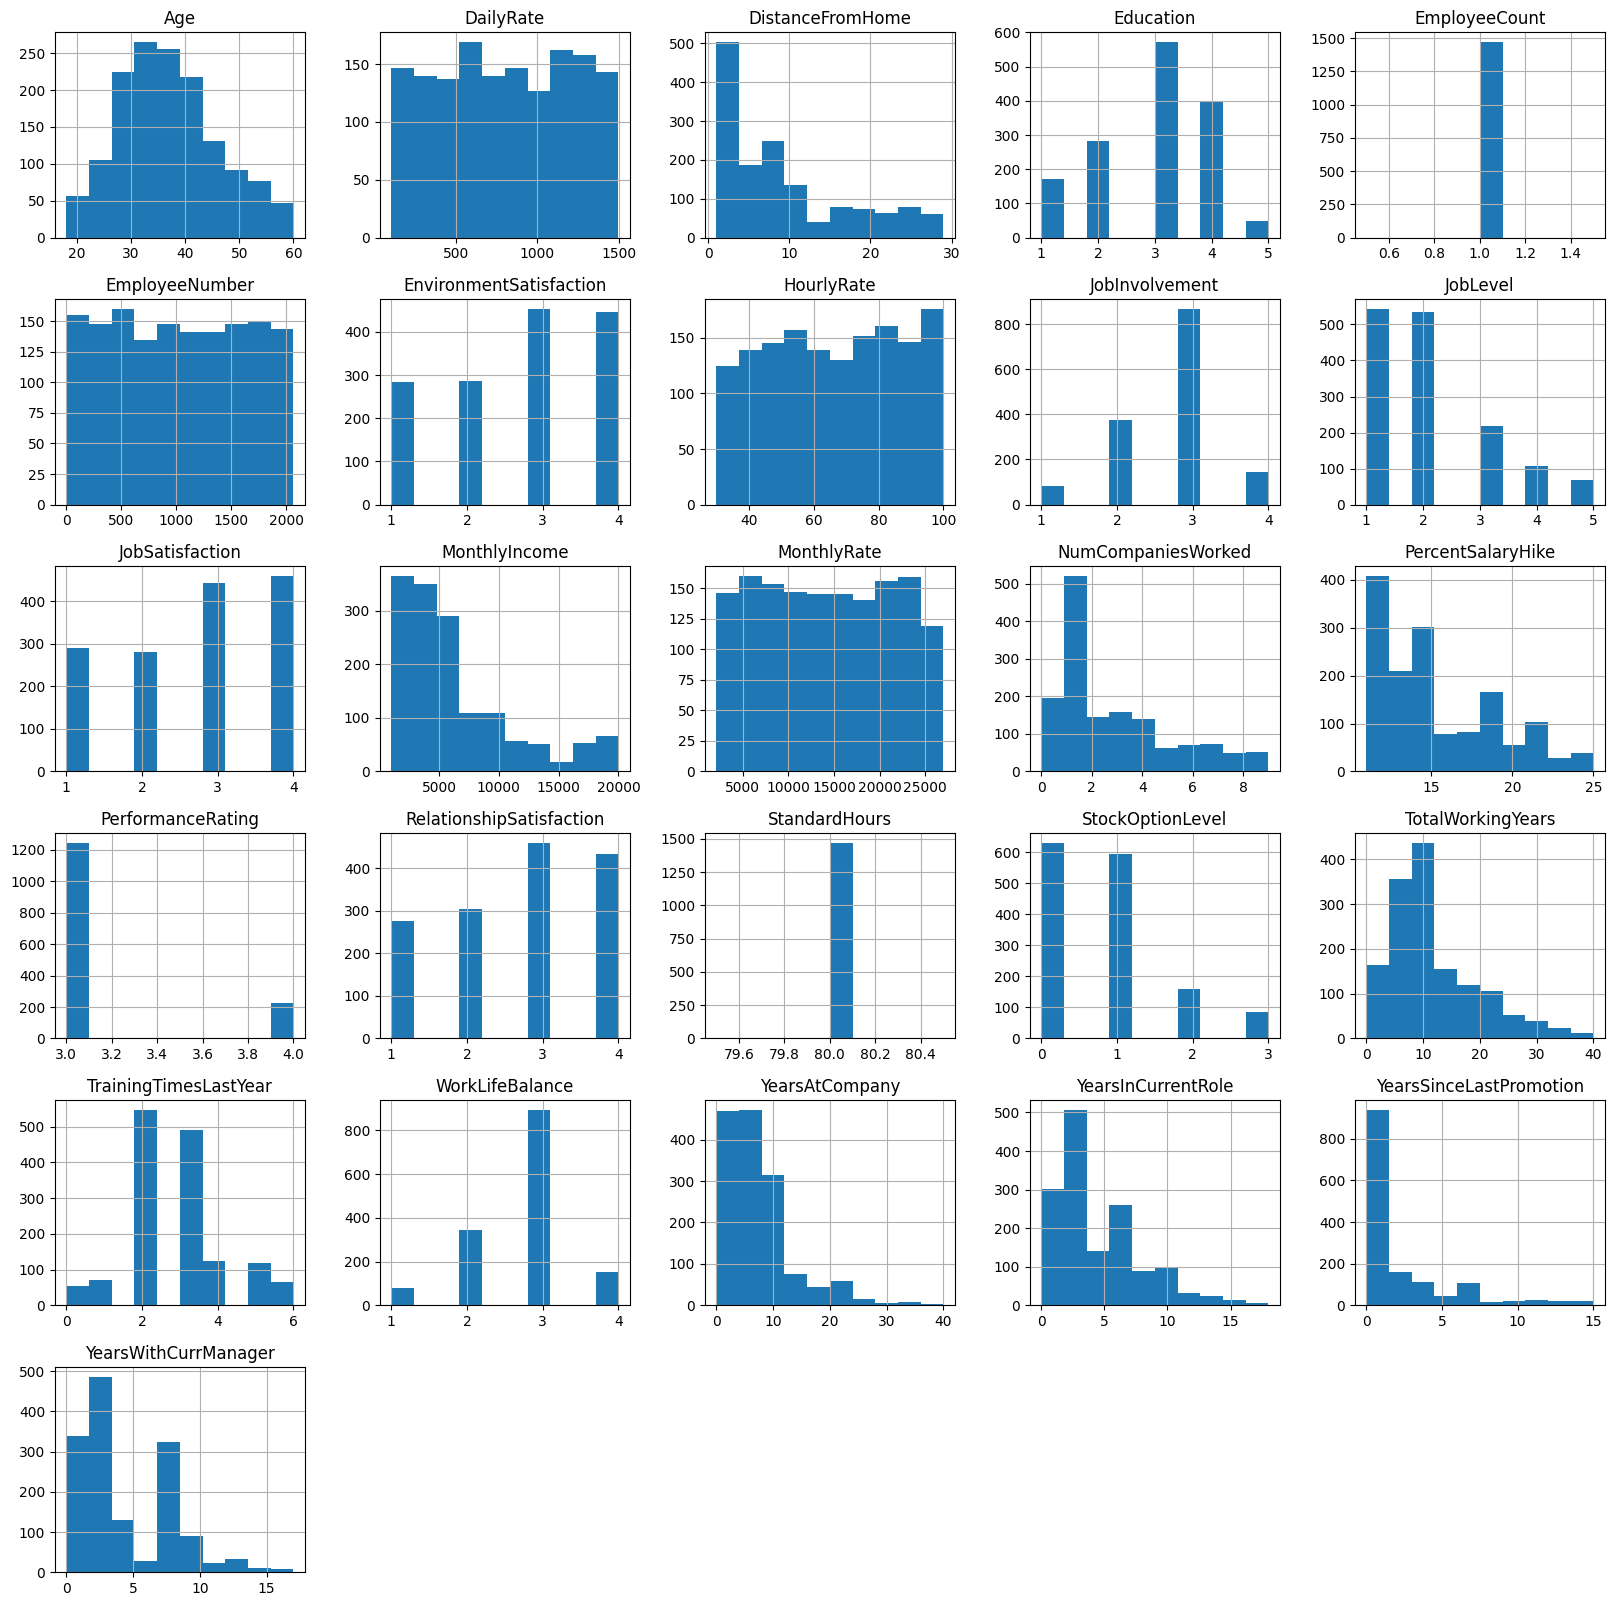

In [ ]:
import matplotlib.pyplot as plt
data.hist(figsize=(20, 20))
plt.show()

In [ ]:
age_leave = data.loc[data['Attrition'] == 'Yes', 'Age']
age_left = data.loc[data['Attrition'] == 'No', 'Age']
print('leave', age_leave.mean(), age_leave.std())
print('left', age_left.mean(), age_left.std())
n1 = age_leave.shape[0]
n2 = age_left.shape[0]
n1, n2
s1 = age_leave.std()
s2 = age_left.std()
x1 = age_leave.mean()
x2 = age_left.mean()
T = (x1 - x2) / np.sqrt(s1**2/n1 + s2**2/n2)
print(T)

leave 33.607594936708864 9.689349895351622
left 37.561232765612324 8.888360024976546
-5.828011853988949


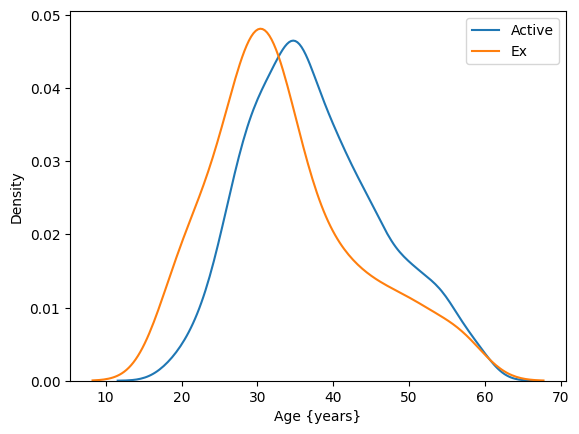

In [ ]:
import seaborn as sns
sns.kdeplot(data.loc[data['Attrition'] == 'No', 'Age'], label = 'Active')
sns.kdeplot(data.loc[data['Attrition'] == 'Yes', 'Age'], label = 'Ex')
plt.xlabel('Age {years}')
plt.ylabel('Density')
plt.legend()


In [ ]:
data['Gender'].value_counts()


,count
Gender,
Male,882
Female,588


<BarContainer object of 2 artists>

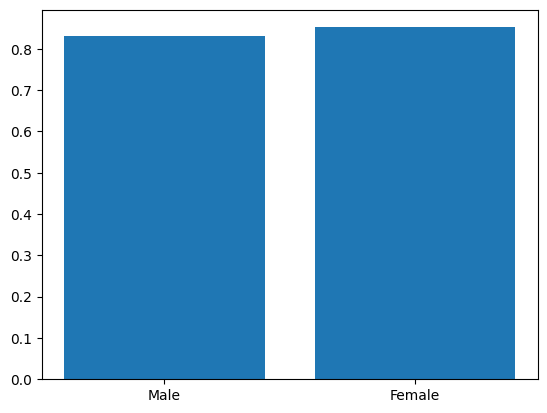

In [ ]:
genders=list(set(data['Gender']))
coef = []
for i, gender in enumerate(genders):
  s1 = data.query('Gender=="'+gender+'"')
  coef.append([gender, s1.query('Attrition == "No"').shape[0] / s1.shape[0]])
coef = np.array(coef)
plt.bar(coef[:, 0], coef[:, 1].astype(float))

13.12.2025

In [ ]:
from statsmodels.stats.proportion import proportion_confint
p = proportion_confint(data.query('Attrition == "No"').shape[0], data.shape[0], method='wilson')
genders = list(set(data["Gender"]))
coefs = []
for i, gender in enumerate(genders):
  s1 = data.query('Gender=="'+gender+'"')
  s2 = data.query('Attrition == "No"')
  wilson_interval = proportion_confint(s2.shape[0], s1.shape[0], method='wilson')
  coefs.append([gender, wilson_interval[0], wilson_interval[1]])
coefs = np.array(coefs)

NameError: name 'data' is not defined

In [ ]:
def intersect_intervals(i1,i2):
    if(i2[0]<=i1[0]<=i2[1]): return True
    if(i2[0]<=i1[1]<=i2[1]): return True
    if(i1[0]<=i2[0]<=i1[1]): return True
    if(i1[0]<=i2[1]<=i1[1]): return True
    return False
intersect_intervals(p,coefs[0,1:].astype(float)),  intersect_intervals(p,coefs[1,1:].astype(float))

(False, False)

In [ ]:
data['EducationField'].value_counts()

,count
EducationField,
Life Sciences,606
Medical,464
Marketing,159
Technical Degree,132
Other,82
Human Resources,27


Technical Degree : True (0.1433125454143761, 0.18090242082971547) (0.17727462637976993, 0.3221418213649679)
Life Sciences : True (0.1433125454143761, 0.18090242082971547) (0.12090760557369681, 0.17727064418376878)
Human Resources : True (0.1433125454143761, 0.18090242082971547) (0.1317037456190719, 0.4467857131455308)
Marketing : True (0.1433125454143761, 0.18090242082971547) (0.16274896388552368, 0.290707172871403)
Other : True (0.1433125454143761, 0.18090242082971547) (0.07658691429563845, 0.22445012742882525)
Medical : True (0.1433125454143761, 0.18090242082971547) (0.10758266955719337, 0.16995036299616445)


<BarContainer object of 6 artists>

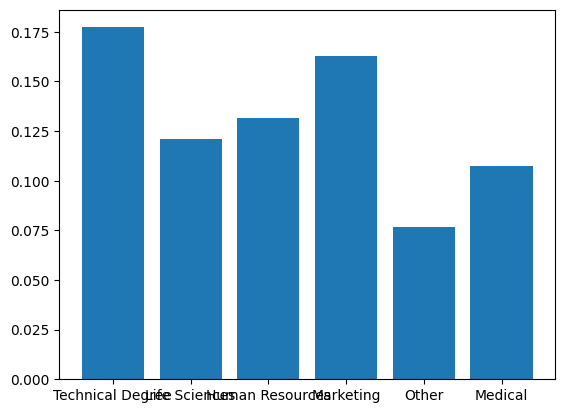

In [ ]:
educations=list(set(data['EducationField']))
p= proportion_confint(data.query('Attrition == "Yes"').shape[0], data.shape[0], method = 'wilson')
coefs=[]
for i,edu in enumerate(educations):
 s1=data.query('EducationField=="'+edu+'"')
 s2=s1.query('Attrition == "Yes"')
 wilson_interval = proportion_confint(s2.shape[0], s1.shape[0], method = 'wilson')
 coefs.append([edu,wilson_interval[0],wilson_interval[1]])
 print(edu,':',intersect_intervals(p,wilson_interval),p,wilson_interval)
coefs=np.array(coefs)
plt.bar(coefs[:,0],coefs[:,1].astype(float))

In [ ]:
fields=[]
for col in data.columns:
    len1=len(set(data[col]))
    if(len1/data.shape[0]<0.01):
        fields.append(col)
fields

['Attrition',
 'BusinessTravel',
 'Department',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EnvironmentSatisfaction',
 'Gender',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TrainingTimesLastYear',
 'WorkLifeBalance']

In [ ]:
for field in fields:
 educations=list(set(data[field]))
 s0=data.query('Attrition == "Yes"') #/ data.shape[0]
 p0 = s0.shape[0]/data.shape[0]
 coefs=[]
 for i,edu in enumerate(educations):
  try:
   s1=data.query(field+'=="'+edu+'"')
  except:
   s1=data.query(field+'=='+str(edu)+'')
  s2=s1.query('Attrition == "Yes"')
  p = s2.shape[0]/s1.shape[0]
  n=s1.shape[0]
  Z=(p-p0)/np.sqrt(p0*(1-p0)/n)
  if(abs(Z)>1.96):
     print(field,edu,'mean',p0,'churn',p)

Attrition No mean 0.16122448979591836 churn 0.0
Attrition Yes mean 0.16122448979591836 churn 1.0
BusinessTravel Travel_Frequently mean 0.16122448979591836 churn 0.2490974729241877
BusinessTravel Non-Travel mean 0.16122448979591836 churn 0.08
Department Sales mean 0.16122448979591836 churn 0.2062780269058296
EducationField Technical Degree mean 0.16122448979591836 churn 0.24242424242424243
EducationField Marketing mean 0.16122448979591836 churn 0.22012578616352202
EnvironmentSatisfaction 1 mean 0.16122448979591836 churn 0.2535211267605634
JobInvolvement 1 mean 0.16122448979591836 churn 0.3373493975903614
JobInvolvement 4 mean 0.16122448979591836 churn 0.09027777777777778
JobLevel 1 mean 0.16122448979591836 churn 0.26335174953959484
JobLevel 2 mean 0.16122448979591836 churn 0.09737827715355805
JobLevel 4 mean 0.16122448979591836 churn 0.04716981132075472
JobLevel 5 mean 0.16122448979591836 churn 0.07246376811594203
JobRole Sales Representative mean 0.16122448979591836 churn 0.39759036144

In [ ]:

for col in data.columns:
  len1 = len(set(data[col]))
  if(len1 / data.shape[0] > 0.01):
    print(col, len1, data.shape[0], len1/data.shape[0])

Age 43 1470 0.029251700680272108
DailyRate 886 1470 0.6027210884353742
DistanceFromHome 29 1470 0.019727891156462583
EmployeeNumber 1470 1470 1.0
HourlyRate 71 1470 0.04829931972789116
MonthlyIncome 1349 1470 0.917687074829932
MonthlyRate 1427 1470 0.9707482993197278
PercentSalaryHike 15 1470 0.01020408163265306
TotalWorkingYears 40 1470 0.027210884353741496
YearsAtCompany 37 1470 0.025170068027210883
YearsInCurrentRole 19 1470 0.01292517006802721
YearsSinceLastPromotion 16 1470 0.010884353741496598
YearsWithCurrManager 18 1470 0.012244897959183673


In [ ]:
import scipy.stats as ss
s1=data #.query('Attrition == "Yes"')
s2=data.query('Attrition == "Yes"')

NameError: name 'data' is not defined

Power_divergenceResult(statistic=np.float64(570.7653024415856), pvalue=np.float64(7.613081562739121e-97))

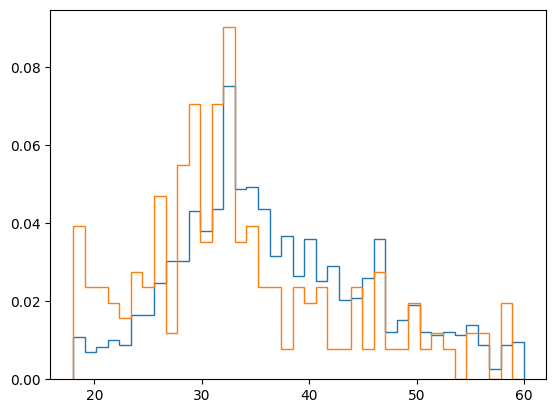

In [ ]:
min1 = np.minimum(s1['Age'].min(), s2['Age'].min())
max1 = np.maximum(s1['Age'].max(), s2['Age'].max())
bins = np.linspace(min1, max1, 40)
dist1 = plt.hist(s1['Age'], histtype='step', density=True, bins=bins)
dist2 = plt.hist(s2['Age'], histtype='step', density=True, bins=bins)
ss.chisquare(dist2[0]*s1.shape[0], f_exp=dist1[0] * s1.shape[0], ddof=1)

In [ ]:
from sklearn.datasets import fetch_california_housing
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
X, y = fetch_california_housing(as_frame=True, return_X_y=True)
print(X.shape)
X.head(),'\n',y.head()

(20640, 8)


(   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 
    Longitude  
 0    -122.23  
 1    -122.22  
 2    -122.24  
 3    -122.25  
 4    -122.25  ,
 '\n',
 0    4.526
 1    3.585
 2    3.521
 3    3.413
 4    3.422
 Name: MedHouseVal, dtype: float64)

(array([   5.,    4.,    5.,    9.,   13.,   48.,   90.,  165.,  274.,
         264.,  323.,  353.,  258.,  288.,  406.,  397.,  482.,  399.,
         337.,  369.,  453.,  359.,  360.,  355.,  351.,  485.,  428.,
         387.,  419.,  502.,  563.,  397.,  442.,  344.,  407.,  410.,
         403.,  300.,  252.,  253.,  303.,  317.,  303.,  358.,  310.,
         268.,  272.,  236.,  227.,  205.,  205.,  234.,  223.,  240.,
         173.,  158.,  167.,  153.,  112.,  104.,   99.,  125.,  105.,
         127.,  111.,  134.,  118.,  134.,  107.,  179.,   91.,  102.,
          94.,   66.,   82.,   67.,   65.,   52.,   69.,   64.,   48.,
          56.,   47.,   52.,   41.,   39.,   50.,   40.,   44.,   62.,
          33.,   33.,   22.,   27.,   29.,   22.,   30.,   17.,   19.,
        1011.]),
 array([0.14999  , 0.1984902, 0.2469904, 0.2954906, 0.3439908, 0.392491 ,
        0.4409912, 0.4894914, 0.5379916, 0.5864918, 0.634992 , 0.6834922,
        0.7319924, 0.7804926, 0.8289928, 0.877493 , 0.

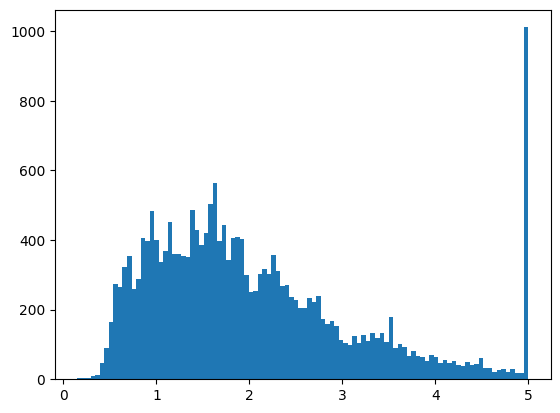

In [ ]:
plt.hist(y, bins=100)

In [ ]:
X = np.array(X)
print(X)
y = np.array(y)
print(y)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, y)
lr.score(X, y)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


0.606232685199805

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 1.000e+00,
        2.000e+00, 2.000e+00, 6.000e+00, 4.000e+00, 1.300e+01, 1.900e+01,
        1.800e+01, 2.100e+01, 3.100e+01, 4.800e+01, 8.500e+01, 1.260e+02,
        2.320e+02, 3.920e+02, 6.010e+02, 9.680e+02, 1.369e+03, 1.674e+03,
        1.818e+03, 1.778e+03, 1.708e+03, 1.583e+03, 1.347e+03, 1.125e+03,
        9.320e+02, 7.700e+02, 6.270e+02, 5.730e+02, 4.560e+02, 4.030e+02,
        2.680e+02, 2.150e+02, 2.150e+02, 1.820e+02, 1.300e+02, 1.320e+02,
        1.120e+02, 9.200e+01, 9.600e+0

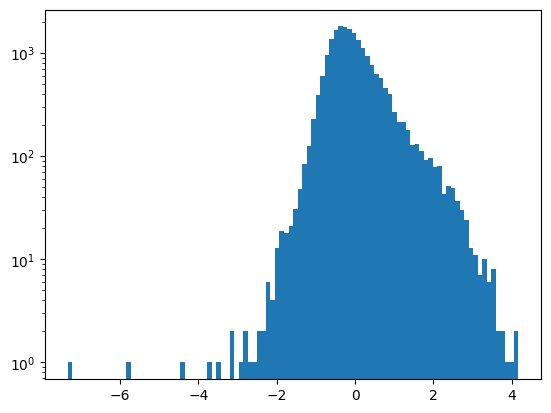

In [ ]:
yp = lr.predict(X)
plt.yscale('log')
plt.hist(y-yp, bins=100)

array([array([0.14999  , 0.1984902, 0.2469904, 0.2954906, 0.3439908, 0.392491 ,
              0.4409912, 0.4894914, 0.5379916, 0.5864918, 0.634992 , 0.6834922,
              0.7319924, 0.7804926, 0.8289928, 0.877493 , 0.9259932, 0.9744934,
              1.0229936, 1.0714938, 1.119994 , 1.1684942, 1.2169944, 1.2654946,
              1.3139948, 1.362495 , 1.4109952, 1.4594954, 1.5079956, 1.5564958,
              1.604996 , 1.6534962, 1.7019964, 1.7504966, 1.7989968, 1.847497 ,
              1.8959972, 1.9444974, 1.9929976, 2.0414978, 2.089998 , 2.1384982,
              2.1869984, 2.2354986, 2.2839988, 2.332499 , 2.3809992, 2.4294994,
              2.4779996, 2.5264998, 2.575    , 2.6235002, 2.6720004, 2.7205006,
              2.7690008, 2.817501 , 2.8660012, 2.9145014, 2.9630016, 3.0115018,
              3.060002 , 3.1085022, 3.1570024, 3.2055026, 3.2540028, 3.302503 ,
              3.3510032, 3.3995034, 3.4480036, 3.4965038, 3.545004 , 3.5935042,
              3.6420044, 3.6905046, 3.73

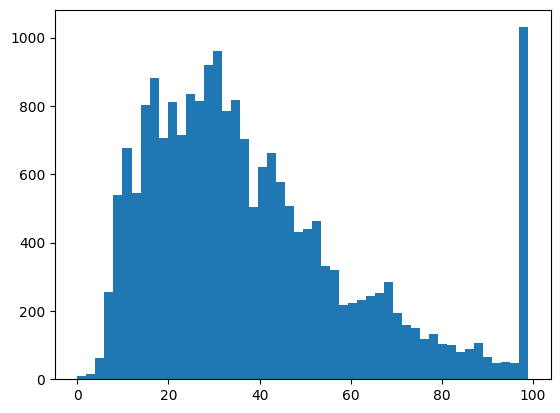

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
dis = KBinsDiscretizer(n_bins = 100, encode='ordinal', strategy='uniform')
y = np.array(y)
y_dis = dis.fit_transform(y.reshape(y.shape[0], 1))[:, 0]
plt.hist(y_dis, bins = 50)
dis.bin_edges_

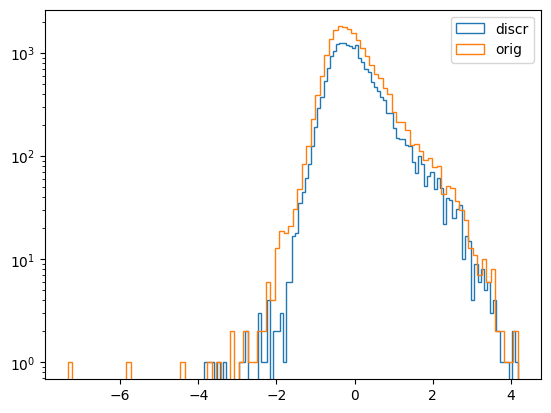

In [ ]:
lr.fit(X, y_dis)
y_dis_p = np.clip(lr.predict(X), 0, dis.bin_edges_[0].shape[0]-2)
yp2 = [0.5*(dis.bin_edges_[0][x]+dis.bin_edges_[0][x+1]) for x in y_dis_p.astype(int)]
plt.yscale('log')
plt.hist(y-yp2, bins=100, label='discr', histtype='step')
plt.hist(y-yp, bins=100, label='orig', histtype='step')
plt.legend()

20.12.2025

(array([   9.,   14.,   61.,  255.,  538.,  676.,  546.,  803.,  881.,
         706.,  812.,  715.,  836.,  815.,  921.,  960.,  786.,  817.,
         703.,  505.,  620.,  661.,  578.,  508.,  432.,  439.,  463.,
         331.,  320.,  216.,  224.,  232.,  245.,  252.,  286.,  193.,
         160.,  149.,  117.,  133.,  104.,   99.,   80.,   90.,  106.,
          66.,   49.,   51.,   47., 1030.]),
 array([ 0.  ,  1.98,  3.96,  5.94,  7.92,  9.9 , 11.88, 13.86, 15.84,
        17.82, 19.8 , 21.78, 23.76, 25.74, 27.72, 29.7 , 31.68, 33.66,
        35.64, 37.62, 39.6 , 41.58, 43.56, 45.54, 47.52, 49.5 , 51.48,
        53.46, 55.44, 57.42, 59.4 , 61.38, 63.36, 65.34, 67.32, 69.3 ,
        71.28, 73.26, 75.24, 77.22, 79.2 , 81.18, 83.16, 85.14, 87.12,
        89.1 , 91.08, 93.06, 95.04, 97.02, 99.  ]),
 <BarContainer object of 50 artists>)

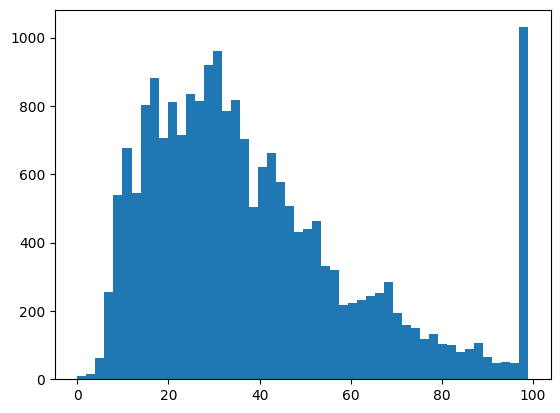

In [ ]:
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
dis = KBinsDiscretizer(n_bins = 100, encode='ordinal', strategy='uniform')
y_dis = dis.fit_transform(y.reshape(y.shape[0], 1))[:, 0]
plt.hist(y_dis, bins = 50)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


(array([ 396.,  429.,  410.,  414.,  412.,  357.,  472.,  413.,  411.,
         206.,  410.,  411.,  415.,  367.,  463.,  413.,  407.,  414.,
         414.,  209.,  401.,  420.,  413.,  409.,  418.,  411.,  413.,
         414.,  412.,  209.,  414.,  406.,  419.,  354.,  473.,  410.,
         415.,  410.,  416.,  203.,  415.,  412.,  414.,  412.,  410.,
         416.,  412.,  414.,  411., 1241.]),
 array([ 0. ,  1.9,  3.8,  5.7,  7.6,  9.5, 11.4, 13.3, 15.2, 17.1, 19. ,
        20.9, 22.8, 24.7, 26.6, 28.5, 30.4, 32.3, 34.2, 36.1, 38. , 39.9,
        41.8, 43.7, 45.6, 47.5, 49.4, 51.3, 53.2, 55.1, 57. , 58.9, 60.8,
        62.7, 64.6, 66.5, 68.4, 70.3, 72.2, 74.1, 76. , 77.9, 79.8, 81.7,
        83.6, 85.5, 87.4, 89.3, 91.2, 93.1, 95. ]),
 <BarContainer object of 50 artists>)

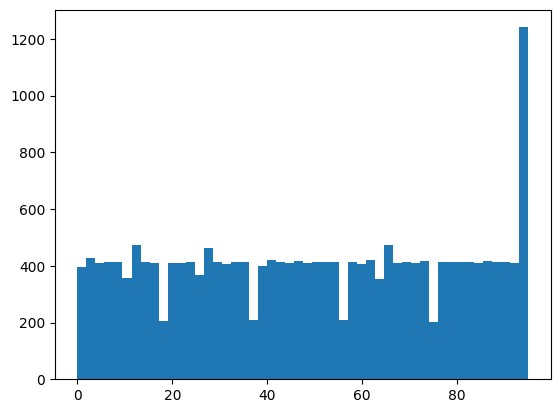

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
dis = KBinsDiscretizer(n_bins = 100, encode='ordinal', strategy='quantile')
y_dis = dis.fit_transform(y.reshape(y.shape[0], 1))[:, 0]
plt.hist(y_dis, bins = 50)

In [ ]:
dis.bin_edges_

array([array([0.14999, 0.5    , 0.55   , 0.588  , 0.625  , 0.662  , 0.69   ,
              0.719  , 0.75   , 0.789  , 0.823  , 0.854  , 0.875  , 0.9    ,
              0.92446, 0.944  , 0.96524, 0.988  , 1.013  , 1.042  , 1.072  ,
              1.1    , 1.125  , 1.142  , 1.17   , 1.196  , 1.22514, 1.25   ,
              1.281  , 1.31031, 1.34   , 1.36609, 1.381  , 1.406  , 1.429  ,
              1.453  , 1.47704, 1.504  , 1.52882, 1.552  , 1.573  , 1.59399,
              1.613  , 1.625  , 1.647  , 1.667  , 1.694  , 1.719  , 1.745  ,
              1.771  , 1.797  , 1.824  , 1.846  , 1.872  , 1.894  , 1.919  ,
              1.945  , 1.977  , 2.01262, 2.052  , 2.094  , 2.128  , 2.161  ,
              2.189  , 2.224  , 2.25   , 2.28   , 2.31313, 2.348  , 2.386  ,
              2.4193 , 2.46069, 2.503  , 2.55   , 2.603  , 2.64725, 2.691  ,
              2.737  , 2.781  , 2.839  , 2.9    , 2.966  , 3.05898, 3.15   ,
              3.24   , 3.32115, 3.4    , 3.482  , 3.544  , 3.647  , 3.766  ,

In [ ]:
import pandas as pd
data=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
import scipy.stats as ss
d = "Age"
dis = KBinsDiscretizer(n_bins = 10, encode = 'ordinal', strategy = 'uniform')
data2 = data.copy()
data2[d+'Coded']=dis.fit_transform(np.array(data2[d]).reshape(data2.shape[0],1))[:,0]
print(data2.head())
print(set(data2[d+'Coded']))
print(dis.bin_edges_)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  StandardHours StockOptionLevel  TotalWorkingYears  \
0  ...       

In [ ]:
def intersect_intervals(i1,i2):
    if(i2[0]<=i1[0]<=i2[1]): return True
    if(i2[0]<=i1[1]<=i2[1]): return True
    if(i1[0]<=i2[0]<=i1[1]): return True
    if(i1[0]<=i2[1]<=i1[1]): return True
    return False

In [ ]:
col = d + 'Coded'
select = list(set(data2[col]))
coefs = []
p = proportion_confint(data2.query('Attrition == "No"').shape[0], data2.shape[0], method = 'wilson')
for i, sel in enumerate(select):
  s1 = data2.query(col+'=='+str(sel)+'')
  s2 = s1.query('Attrition == "No"')
  wilson_interval = proportion_confint(s2.shape[0], s1.shape[0], method='wilson')
  coefs.append([sel, wilson_interval[0], wilson_interval[1]])
  # print(sel, ':', intersect_intervals(p, wilson_interval), p, wilson_interval)
  res = intersect_intervals(p, wilson_interval)
  if not res:
    print('====RISK====', col, sel, ':', intersect_intervals(p, wilson_interval), p, wilson_interval)
    print('====RISK VALUES====', dis.bin_edges_[0][i], '..', dis.bin_edges_[0][i+1])
coefs = np.array(coefs)
# p = proportion_count(data2.query('Attriyion == "No"').shape[0], data.shape[0], method='')

====RISK==== AgeCoded 0.0 : False (0.8190975791702844, 0.8566874545856238) (0.39918016218741176, 0.6501283201887471)
====RISK VALUES==== 18.0 .. 22.2
====RISK==== AgeCoded 1.0 : False (0.8190975791702844, 0.8566874545856238) (0.6315420694448662, 0.8002786770725797)
====RISK VALUES==== 22.2 .. 26.4
====RISK==== AgeCoded 4.0 : False (0.8190975791702844, 0.8566874545856238) (0.8637807084616567, 0.9359366202194261)
====RISK VALUES==== 34.8 .. 39.0


In [ ]:
import warnings
warnings.filterwarnings('ignore')

coefs = []
for col in data.columns:
    len1 = len(set(data[col]))
    if len1 / data.shape[0] > 0.01:
        d = col
        dis = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
        data2 = data.copy()
        data2[d + 'Coded'] = dis.fit_transform(np.array(data2[d]).reshape(-1, 1))[:, 0]
        col_coded = d + 'Coded'

        p = proportion_confint(data2.query('Attrition == "No"').shape[0], data2.shape[0], method='wilson')

        unique_bins = sorted(data2[col_coded].unique())

        for i, sel in enumerate(unique_bins):
            s1 = data2.query(col_coded + '==' + str(sel))
            s2 = s1.query('Attrition == "No"')

            if s1.shape[0] > 0:
                wilson_interval = proportion_confint(s2.shape[0], s1.shape[0], method='wilson')
                coefs.append([sel, wilson_interval[0], wilson_interval[1]])

                res = intersect_intervals(p, wilson_interval)
                if not res:
                    print('====RISK====', col_coded, sel, ':', intersect_intervals(p, wilson_interval), p, wilson_interval)
                    print('====RISK VALUES====', dis.bin_edges_[0][int(sel)], '..', dis.bin_edges_[0][int(sel)+1])

====RISK==== AgeCoded 0.0 : False (0.8190975791702844, 0.8566874545856238) (0.554439738066514, 0.7214952781766906)
====RISK VALUES==== 18.0 .. 26.0
====RISK==== AgeCoded 6.0 : False (0.8190975791702844, 0.8566874545856238) (0.863493763930836, 0.9509728602872312)
====RISK VALUES==== 38.0 .. 41.0
====RISK==== DailyRateCoded 1.0 : False (0.8190975791702844, 0.8566874545856238) (0.6724302164752693, 0.8115216132851111)
====RISK VALUES==== 242.8 .. 391.8
====RISK==== MonthlyIncomeCoded 0.0 : False (0.8190975791702844, 0.8566874545856238) (0.6081611102463781, 0.7564601313539084)
====RISK VALUES==== 1009.0 .. 2317.6
====RISK==== MonthlyIncomeCoded 1.0 : False (0.8190975791702844, 0.8566874545856238) (0.6081611102463781, 0.7564601313539084)
====RISK VALUES==== 2317.6 .. 2695.8
====RISK==== MonthlyIncomeCoded 9.0 : False (0.8190975791702844, 0.8566874545856238) (0.9228527902356296, 0.9853855752050842)
====RISK VALUES==== 13775.600000000008 .. 19999.0
====RISK==== TotalWorkingYearsCoded 0.0 : Fal